# Figure 4 — Reversal Probe

Reconstructs Figure 4 of the 2S2C manuscript from the rebuilt parquet pipeline. Panels:

- **A** — session schematic (`figures/images/fig_4a.svg`), top of the left column, kept at its original
  rendered size (knob `A_WIDTH_IN`).
- **B** — **reversal trials to criterion** (learning rate), box-and-whisker plot: box = group median
  and IQR of the censoring-capped TTC, whiskers = Tukey 1.5 × IQR (knob `box_whis`), per-rat symbols;
  **open** symbols in the shaded "not reached" band above the session-end line (64) are rats that
  never reached criterion (right-censored, not excluded or imputed; the VC$^{\mathrm{VC}}$ box sits on
  the line as a lower bound). Statistics are non-parametric: **Kruskal–Wallis** on the capped TTC
  (primary, with ε²), Mann–Whitney pairs (Holm headline, Bonferroni tabled; knob `TTC_PADJUST`), the
  PI$_{\mathrm{PI}}$ vs PI$_{\mathrm{PI+VC}}$ cue-exposure pair; the censoring-aware k-sample log-rank
  (asymptotic + label-permutation p, Holm pairs) and an 8-consecutive-correct robustness definition
  are kept as supporting checks. Knob `FIG4B_STYLE = 'bar'` restores the earlier mean ± SEM (RMST) bars.
- **C** — **Kaplan–Meier curves** of the same data: proportion of rats not yet at criterion across
  reversal trials (censored rats leave the curve standing at their censoring point).
- **D** — reversal accuracy across Phase-1 | Phase-2 blocks, with the carry-forward imputation
  (the panel function keeps its historical `panel_b_accuracy` name).
- **E** — reversal perseveration (% pre-reversal responses; chance 0.5; criterion-imputed 0 after
  a rat stops — the mirror of Panel D's 100% carry-forward).
- **F** — latency to first well entry (s; no imputation; `LAT_MIN_N` hides thin group × block cells).

**Scores and analyses.** Panels E and F plot the per-rat **mean** score per block (group mean ± SEM
across rats). The Panel-D statistics (Phase-1 2 × 5 mixed ANOVA; Phase-2 block × group mixed ANOVA
with Bonferroni post-hocs on the block-averaged score; PI$_{\mathrm{PI}}$ vs PI$_{\mathrm{PI+VC}}$
cue-exposure control with Bayes factor) are applied to both measures, on **mean and median** scores:
latency scores are computed both ways per rat; for perseveration (a proportion) the "median"
analysis is a rank-based complement (Kruskal–Wallis, Bonferroni Mann–Whitney) plus
median ± IQR tables. Statistics precede each panel (assumption checks → tests → panel).

**Layout.** 7.5 × 5.61 in, a 3 × 2 grid of 1.87 in rows. Left column (36%): A | B | C. Right
column (64%): D | E | F with one shared pad set → identical axes widths. Output:
`figures/images/figure4.svg`, with the vector Panel A spliced in and hatch patterns expanded to plain
strokes (see the export cell at the end).

**Groups.** PI rats are split by prior Novel-Route cue exposure (PI$_{\mathrm{PI}}$ vs
PI$_{\mathrm{PI+VC}}$), VC rats by reversal condition (VC$^{\mathrm{PI+VC}}$ vs VC$^{\mathrm{VC}}$);
n = 15 / 6 / 6 / 6 / 6 = 39 after excluding two PI+VC rats whose sessions ended before an 8/8
criterion block (criterion and exclusion are knobs in the data cell).

## Preamble — imports, paths, style

In [1]:
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[1]   # figures/notebooks/ -> repo root
DATA = PROJECT_ROOT / 'data' / 'processed'
CONFIG = PROJECT_ROOT / 'config'
FIG_OUT = PROJECT_ROOT / 'figures' / 'images'
FIG_OUT.mkdir(exist_ok=True)

pd.set_option('display.max_columns', None, 'display.width', 200)

In [2]:
# 5-group palette. PI+VC keeps figure2's green; each PI/VC subgroup is
# color-matched to its figure3 counterpart (same subjects):
#   PI_PI      == fig3 PI_PI      blue    (subjects 93,94,95,96,97,98)
#   PI_PI+VC   == fig3 PI_PI+VC   l.blue  (subjects 67,68,69,78,80,90)
#   VC^PI+VC   == fig3 VC_VC      orange  (subjects 84,85,87,88,89,100)
#   VC^VC      == fig3 VC_PI+VC   yellow  (subjects 71,73,75,76,82,99)
# PI subgroups = Novel-Route probe split (subscript); VC subgroups = reversal
# probe split (superscript).
GROUP_ORDER = ['PI+VC', 'PI_PI', 'PI_PI+VC', 'VC^PI+VC', 'VC^VC']

# Legend display strings (sub/superscripts via mathtext) — tunable.
GROUP_LABELS = {
    'PI+VC':    'PI+VC',
    'PI_PI':    r'PI$_{\mathrm{PI}}$',
    'PI_PI+VC': r'PI$_{\mathrm{PI+VC}}$',
    'VC^PI+VC': r'VC$^{\mathrm{PI+VC}}$',
    'VC^VC':    r'VC$^{\mathrm{VC}}$',
}

STYLE = {
    'PI+VC':    {'fill': '#8FD4BE', 'base': '#009E73', 'edge': '#00624A',
                 'hatch_color': '#47B998', 'hatch': '',    'line': '-',  'marker': 'o'},
    'PI_PI':    {'fill': '#AADCF4', 'base': '#56B4E9', 'edge': '#2B6F94',
                 'hatch_color': '#80C8EE', 'hatch': '///', 'line': '--', 'marker': 's'},        # = fig3 PI_PI
    'PI_PI+VC': {'fill': '#D4E9F8', 'base': '#7FC4EE', 'edge': '#3F8CBE',
                 'hatch_color': '#A6D5F2', 'hatch': '\\\\\\', 'line': ':',  'marker': 'D'},        # = fig3 PI_PI+VC
    'VC^PI+VC': {'fill': '#F4CF80', 'base': '#E69F00', 'edge': '#8A5F00',
                 'hatch_color': '#EDB740', 'hatch': '...', 'line': '-.', 'marker': '^'},        # = fig3 VC_VC
    'VC^VC':    {'fill': '#FAE2B0', 'base': '#F0B547', 'edge': '#A77B1E',
                 'hatch_color': '#F2C97A', 'hatch': 'xxx', 'line': (0, (3, 1, 1, 1)), 'marker': 'D'},  # = fig3 VC_PI+VC
}

STYLE_CFG = {
    'bar_edge_lw':         0.5,
    'legend_frame_lw':     0.5,
    'legend_content_color': '0.3',
    'marker_edge_lw':      0.6,
    'marker_size':         3.2,
    'err_lw':              0.9,
    'cap_size':            2,
    'axhline_lw':          0.8,
}

# --- Helvetica bold / oblique faces ------------------------------------------
# macOS ships Helvetica as a .ttc collection and matplotlib's font manager indexes
# only its first face (Regular, weight 400), so fontweight='bold' silently fell back
# to regular (the PDF embedded no Helvetica-Bold; panel letters rendered regular).
# Split the collection into standalone .ttf faces once (user-local, outside the
# repo) and register them so 'bold' resolves to Helvetica-Bold.ttf. Same fix as
# figure2 / figure3's style cell.
from matplotlib import font_manager as _fm
_HELV_TTC = Path('/System/Library/Fonts/Helvetica.ttc')
_HELV_DIR = Path.home() / '.matplotlib' / 'helvetica_faces'
if _HELV_TTC.exists():
    if not any(_HELV_DIR.glob('*.ttf')):
        from fontTools.ttLib import TTCollection
        _HELV_DIR.mkdir(parents=True, exist_ok=True)
        for _face in TTCollection(str(_HELV_TTC)).fonts:
            _face.save(str(_HELV_DIR / f"{_face['name'].getDebugName(6)}.ttf"))
    for _p in _HELV_DIR.glob('*.ttf'):
        _fm.fontManager.addfont(str(_p))
_bold_face = Path(_fm.findfont(_fm.FontProperties(family='Helvetica', weight='bold'))).name
if 'Bold' not in _bold_face:
    print(f'WARNING: Helvetica bold resolved to {_bold_face}; panel letters will render regular')
else:
    print(f'Helvetica bold face: {_bold_face}')

plt.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 8,
    'mathtext.default': 'regular',  # subgroup sub/superscripts use the figure font
    'axes.labelsize': 7,
    'axes.titlesize': 7,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'axes.linewidth': 0.75,
    'xtick.major.width': 0.75,
    'ytick.major.width': 0.75,
    'xtick.minor.width': 0.75,
    'ytick.minor.width': 0.75,
    'lines.linewidth': 0.75,
    'patch.linewidth': 0.75,
    'hatch.linewidth': 0.75,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 200,
    'savefig.dpi': 300,
})

Helvetica bold face: Helvetica-Bold.ttf


## Load cohort and parquets

In [3]:
cohort = yaml.safe_load((CONFIG / 'subjects.yaml').read_text())['figure4']
subj_to_group = {sid: g for g, ids in cohort.items() for sid in ids}
cohort_ids = list(subj_to_group)

subjects = pd.read_parquet(DATA / 'subjects.parquet')
sessions = pd.read_parquet(DATA / 'sessions.parquet')
trials   = pd.read_parquet(DATA / 'trials.parquet')

subjects = subjects[subjects['subject_id'].isin(cohort_ids)].copy()
subjects['group'] = subjects['subject_id'].map(subj_to_group)

# Split the PI reversal group (all reverse without a cue, PI^PI) by whether
# each rat saw a cue during the *earlier Novel-Route probe* — the cue-exposure
# control. subjects.novel_route_probe gives PI_PI (no cue) / PI_PI+VC (cue),
# the same 6/6 subject sets as figure3. Non-PI groups are unchanged.
pi = subjects['group'] == 'PI'
subjects.loc[pi, 'group'] = subjects.loc[pi, 'novel_route_probe'].astype(str)
subj_to_group = dict(zip(subjects['subject_id'], subjects['group']))
subjects['group'] = pd.Categorical(subjects['group'], categories=GROUP_ORDER, ordered=True)

sessions = sessions[sessions['subject_id'].isin(cohort_ids)].copy()
sessions['group'] = sessions['subject_id'].map(subj_to_group)
trials = trials.merge(
    sessions[['session_id', 'subject_id', 'group', 'session_experiment_phase']],
    on='session_id', how='inner',
)

# Sanity check: cohort counts. Same 41 rats as figure2/figure3, with PI split 6/6
# by novel_route_probe.
counts = subjects.groupby('group', observed=True)['subject_id'].nunique()
print('Cohort (Figure 4 reversal, PI split by prior cue exposure):')
for g, n in counts.items():
    print(f'  {g:10s} n={n}')
expected = {'PI+VC': 17, 'PI_PI': 6, 'PI_PI+VC': 6, 'VC^PI+VC': 6, 'VC^VC': 6}
for g, n in expected.items():
    assert counts.get(g, 0) == n, f'{g}: got {counts.get(g, 0)}, expected {n}'
print('OK: cohort matches expected counts (17/6/6/6/6 = 41)')

Cohort (Figure 4 reversal, PI split by prior cue exposure):
  PI+VC      n=17
  PI_PI      n=6
  PI_PI+VC   n=6
  VC^PI+VC   n=6
  VC^VC      n=6
OK: cohort matches expected counts (17/6/6/6/6 = 41)


## Reversal trial table

Per-trial labels:
- `phase`: **P1** (`trial_number <= 16`, goal original) or **P2**
  (`trial_number > 16`, goal relocated).
- `block`: within-phase block of 8 trials. P1 → 1–2; P2 → 1–8.
- `correct`: `errors == 0` (scored against the relocated goal in P2).

Group: PI+VC from `training_group`; the VC subgroups from
`subjects.reversal_probe`; the PI subgroups from `subjects.novel_route_probe`
(the cue-exposure split). Not from the trial-level `cue_on` flag (uniformly 1).

In [4]:
rev_sessions = sessions[sessions['session_experiment_phase'] == 'Reversal'].copy()
probe = trials[trials['session_id'].isin(rev_sessions['session_id'])].copy()
probe = probe[probe['subject_id'].isin(cohort_ids)]

probe['phase'] = np.where(probe['trial_number'] <= 16, 'P1', 'P2')
probe['block'] = np.where(
    probe['phase'] == 'P1',
    (probe['trial_number'] - 1) // 8 + 1,        # P1: 1-2
    (probe['trial_number'] - 17) // 8 + 1,       # P2: 1-8
).astype(int)
probe['correct'] = (probe['errors'] == 0).astype(int)

# ============================ knobs ==========================================
CRIT_CORRECT_OF_8 = 8   # reversal criterion: first Phase-2 block with >= this many of its 8 trials
                        # correct. 8 (= 8/8) is p = .0039 per block under chance, the per-look
                        # analogue of the acquisition rule (>= 24/32, p <= .01); the earlier 7/8
                        # definition is p = .035 per block (decision 2026-09-24).
EXCLUDE_UNMET_CRITERION = True   # drop rats whose session was ended (< 64 reversal trials) before
                                 # they produced a criterion block: their remaining blocks cannot
                                 # be carried forward as 100 % (the Panel D/E imputation) and their
                                 # trials to criterion is neither observed nor censored at 64.
# =============================================================================
_p2 = probe[probe['phase'] == 'P2']
_blk_correct = _p2.groupby(['subject_id', 'block'])['correct'].sum()
_has_crit = (_blk_correct >= CRIT_CORRECT_OF_8).groupby('subject_id').any()
_n_p2 = _p2.groupby('subject_id').size()
unmet_early = sorted(s for s in _n_p2.index if (not _has_crit.get(s, False)) and _n_p2[s] < 64)
if EXCLUDE_UNMET_CRITERION and unmet_early:
    _nm = subjects.set_index('subject_id').loc[unmet_early]
    print(f'Excluded {len(unmet_early)} rat(s) whose session ended before a {CRIT_CORRECT_OF_8}/8 block: '
          + ', '.join(f"{r['name']} ({r['group']}, {int(_n_p2[s])} reversal trials)" for s, r in _nm.iterrows()))
    probe = probe[~probe['subject_id'].isin(unmet_early)].copy()
    subjects = subjects[~subjects['subject_id'].isin(unmet_early)].copy()
    sessions = sessions[~sessions['subject_id'].isin(unmet_early)].copy()
    rev_sessions = rev_sessions[~rev_sessions['subject_id'].isin(unmet_early)].copy()
    trials = trials[~trials['subject_id'].isin(unmet_early)].copy()
    cohort_ids = [s for s in cohort_ids if s not in unmet_early]
    subj_to_group = {k: v for k, v in subj_to_group.items() if k not in unmet_early}
    print('Cohort after exclusion: ' + ', '.join(f'{g} n={n}' for g, n in
          subjects.groupby('group', observed=True)['subject_id'].nunique().items()) + f' = {subjects["subject_id"].nunique()}')
elif unmet_early:
    print(f'NOTE: {len(unmet_early)} rat(s) ended their session before a {CRIT_CORRECT_OF_8}/8 block and are KEPT '
          '(EXCLUDE_UNMET_CRITERION = False): their carry-forward is not criterion-based.')

# --- structural sanity checks ---
n_sess = probe['session_id'].nunique()
n_rats = probe['subject_id'].nunique()
assert probe['trial_number'].max() <= 80, 'unexpected trial_number > 80'
p1_per_rat = probe[probe['phase'] == 'P1'].groupby('subject_id').size()
assert (p1_per_rat == 16).all(), 'some rat lacks a complete 16-trial Phase 1'
print(f'Reversal probe: {n_rats} rats, {n_sess} sessions, {len(probe)} trials.')
print(f'Phase-1 trials per rat: all == 16  (min session length guarantees this).')

# Per (group, phase, block) rat counts — shows the Phase-2 dropoff that the
# carry-forward step below will fill.
nblk = (probe.groupby(['group', 'phase', 'block'], observed=True)['subject_id']
             .nunique().unstack(['phase', 'block']).fillna(0).astype(int))
print('\nRats contributing per (group | phase.block) BEFORE imputation:')
print(nblk.to_string())

Excluded 2 rat(s) whose session ended before a 8/8 block: CM006 (PI+VC, 32 reversal trials), CM007 (PI+VC, 32 reversal trials)
Cohort after exclusion: PI+VC n=15, PI_PI n=6, PI_PI+VC n=6, VC^PI+VC n=6, VC^VC n=6 = 39
Reversal probe: 39 rats, 39 sessions, 2327 trials.
Phase-1 trials per rat: all == 16  (min session length guarantees this).

Rats contributing per (group | phase.block) BEFORE imputation:
phase     P1      P2                        
block      1   2   1   2   3   4  5  6  7  8
group                                       
PI+VC     15  15  15  15  15  11  6  4  3  3
PI_PI      6   6   6   6   6   2  2  2  1  1
PI_PI+VC   6   6   6   6   5   3  1  1  0  0
VC^PI+VC   6   6   6   6   6   6  6  6  6  6
VC^VC      6   6   6   6   6   6  6  6  6  6


## Per-rat × block accuracy, with carry-forward imputation

1. Per-rat accuracy in each (phase, block) it actually ran.
2. **Carry-forward**: fill each rat's missing Phase-2 blocks (after its last
   recorded block, up to block 8) with **1.0** — the assumption that a rat
   which stopped early would have stayed at criterion. With the 8/8 criterion
   (`CRIT_CORRECT_OF_8`), every imputed rat owns an 8/8 block; rats whose
   session ended without one are excluded in the data cell (`EXCLUDE_UNMET_CRITERION`).
3. Sanity guard: print any imputed rat whose *last actual* Phase-2 block was
   below 80% (would undermine the assumption). Expected: none.

In [5]:
# 1. Actual per-rat per-block accuracy.
rat_blk = (probe.groupby(['subject_id', 'group', 'phase', 'block'], observed=True)
                ['correct'].mean().reset_index())

# 2. Complete (rat × block) grid: P1 blocks 1-2 + P2 blocks 1-8.
target_blocks = [('P1', 1), ('P1', 2)] + [('P2', b) for b in range(1, 9)]
grid = pd.MultiIndex.from_tuples(
    [(sid, g, ph, b)
     for sid, g in subjects[['subject_id', 'group']].itertuples(index=False)
     for ph, b in target_blocks],
    names=['subject_id', 'group', 'phase', 'block'],
).to_frame(index=False)

rat_full = grid.merge(rat_blk, on=['subject_id', 'group', 'phase', 'block'], how='left')

# last actual P2 block per rat (0 if none)
last_p2 = (probe[probe['phase'] == 'P2'].groupby('subject_id')['block'].max())

is_p2 = rat_full['phase'] == 'P2'
missing = rat_full['correct'].isna()
beyond_last = rat_full['block'] > rat_full['subject_id'].map(last_p2).fillna(0)
impute_mask = is_p2 & missing & beyond_last
rat_full['imputed'] = impute_mask
rat_full.loc[impute_mask, 'correct'] = 1.0

# 3. Sanity: no leftover NaN (would mean a P1 gap or an internal P2 gap).
leftover = rat_full['correct'].isna().sum()
assert leftover == 0, f'{leftover} block(s) still NaN after carry-forward (unexpected gap)'

# Guard: imputed rats whose last *actual* P2 block was below criterion.
last_block_acc = (
    probe[probe['phase'] == 'P2']
    .sort_values('block')
    .groupby(['subject_id', 'group'], observed=True)
    .apply(lambda d: d.loc[d['block'] == d['block'].max(), 'correct'].mean(),
           include_groups=False)
    .rename('last_actual_p2_acc').reset_index()
)
imputed_rats = rat_full.loc[rat_full['imputed'], 'subject_id'].unique()
guard = last_block_acc[last_block_acc['subject_id'].isin(imputed_rats)]
below = guard[guard['last_actual_p2_acc'] < 0.8]
n_imp_rats = len(imputed_rats)
n_imp_blocks = int(impute_mask.sum())
print(f'Carry-forward: imputed {n_imp_blocks} block-cells across {n_imp_rats} rats.')
if len(below):
    print('WARNING — imputed rats whose last actual P2 block was < 80%:')
    print(below.to_string(index=False))
else:
    print('Guard OK: every imputed rat was at >=80% in its last actual P2 block.')

# Guard 2: the 100 % carry-forward is justified only for rats that met the criterion.
_crit_ok = (probe[probe['phase'] == 'P2'].groupby(['subject_id', 'block'])['correct'].sum()
            >= CRIT_CORRECT_OF_8).groupby('subject_id').any()
_no_crit = [s for s in imputed_rats if not _crit_ok.get(s, False)]
assert not _no_crit, f'imputed rats without a {CRIT_CORRECT_OF_8}/8 block: {_no_crit} (set EXCLUDE_UNMET_CRITERION)'
print(f'Guard OK: every imputed rat has a {CRIT_CORRECT_OF_8}/8 block.')

Carry-forward: imputed 96 block-cells across 23 rats.
Guard OK: every imputed rat was at >=80% in its last actual P2 block.
Guard OK: every imputed rat has a 8/8 block.


In [6]:
# x position: P1 b1->0, P1 b2->1, P2 b1->2, ... P2 b8->9  (10 positions).
rat_full['x_order'] = np.where(rat_full['phase'] == 'P1',
                               rat_full['block'] - 1,
                               rat_full['block'] + 1).astype(int)

def mean_sem(df, value='correct'):
    g = df.groupby(['group', 'x_order'], observed=True)[value]
    return pd.DataFrame({'mean': g.mean(), 'sem': g.sem(), 'n': g.size()}).reset_index()

group_acc = mean_sem(rat_full)

# Block labels for the x axis: block number within each phase.
XORDER_LABEL = {0: '1', 1: '2', 2: '1', 3: '2', 4: '3', 5: '4',
                6: '5', 7: '6', 8: '7', 9: '8'}

# Per-group block-wise Phase-2 means + first block to cross 80% (sanity:
# PI_PI/PI_PI+VC ~block 2, PI+VC ~block 3, VC^PI+VC ~block 7, VC^VC never).
p2_means = (rat_full[rat_full['phase'] == 'P2']
            .groupby(['group', 'block'], observed=True)['correct'].mean()
            .unstack('block'))
print('Phase-2 mean accuracy by group × block (after carry-forward):')
print((p2_means * 100).round(1).to_string())
print('\nFirst Phase-2 block reaching >= 80% mean accuracy:')
for g in GROUP_ORDER:
    row = p2_means.loc[g]
    hit = row[row >= 0.8]
    print(f'  {g:10s} -> {"block " + str(int(hit.index[0])) if len(hit) else "never"}')

Phase-2 mean accuracy by group × block (after carry-forward):
block        1     2      3      4      5      6      7      8
group                                                         
PI+VC      6.7  45.8   80.8   85.0   92.5   90.8   91.7   93.3
PI_PI     35.4  91.7  100.0  100.0  100.0  100.0  100.0  100.0
PI_PI+VC  33.3  85.4  100.0  100.0  100.0  100.0  100.0  100.0
VC^PI+VC   0.0  16.7   45.8   54.2   62.5   77.1   93.8   91.7
VC^VC      6.2   4.2    6.2    4.2    4.2    6.2   10.4    8.3

First Phase-2 block reaching >= 80% mean accuracy:
  PI+VC      -> block 3
  PI_PI      -> block 2
  PI_PI+VC   -> block 2
  VC^PI+VC   -> block 7
  VC^VC      -> never


## Statistics — Panels 4B & 4C, reversal trials to criterion (Kruskal–Wallis, with survival checks)

**Metric.** Per-rat trials to criterion: **first Phase-2 block with 8/8 correct → TTC = 8 × block**
(knob `CRIT_CORRECT_OF_8`; p = .0039 per block under chance, the per-look analogue of the acquisition
rule, decision 2026-09-24; the earlier ≥ 7/8 definition is p = .035). Rats whose session was ended
before they produced such a block are excluded in the data cell (`EXCLUDE_UNMET_CRITERION`: two PI+VC
rats), so TTC is observed for every remaining learner. Rats with no criterion block are **right-censored** — event = 0 at their last
reversal trial; all 9 such rats ran the full 64, so primary-definition censoring sits only at 64.
Capping at 64 therefore leaves every rank order intact (censored rats tie at the top), which keeps
the rank tests clean; the capped mean is a proper restricted mean (RMST) and is tabled for reference.

**Tests.** The TTC is quantised to multiples of 8, right-censored and skewed, so no parametric test
is used. Primary inference is the **Kruskal–Wallis** test on the capped TTC (H, df = 4, ε² effect
size), followed by **Mann–Whitney** pairs over the 10 group pairs — the headline correction is the
`TTC_PADJUST` knob (default **Holm**; Bonferroni ×10 is tabled alongside and the pairs that differ
between the two are printed) — and the PI$_{\mathrm{PI}}$ vs PI$_{\mathrm{PI+VC}}$ cue-exposure pair.
Kept as **supporting checks**: the censoring-aware k-sample **log-rank** χ² (asymptotic + label-
permutation p, pairwise permutation log-rank with Holm), and a robustness re-run with the trial-level
criterion **8 consecutive correct** (there censoring can precede 64 for early-stopped rats, which the
log-rank handles and capped-value tests would not). A plain ANOVA on the capped means is *not* used:
it would treat "> 64" as "= 64".


In [7]:
# Trials to criterion (learning rate) — Kruskal-Wallis on the capped TTC (primary), with
# censoring-aware survival checks (log-rank) as supporting analyses.
from scipy import stats as sps

# --- per-rat TTC, primary definition: first P2 block with >= CRIT_CORRECT_OF_8 of 8 correct -> 8 * block ---
_crit_blk = (rat_blk[(rat_blk['phase'] == 'P2') & (rat_blk['correct'] >= CRIT_CORRECT_OF_8 / 8 - 1e-9)]
             .groupby('subject_id')['block'].min())
_p2_run = probe[probe['phase'] == 'P2'].groupby('subject_id').size()
ttc = subjects[['subject_id', 'name', 'group']].copy()
ttc['group'] = ttc['group'].astype(str)
ttc['first_crit_block'] = ttc['subject_id'].map(_crit_blk)
ttc['event'] = ttc['first_crit_block'].notna().astype(int)
ttc['time'] = np.where(ttc['event'] == 1, ttc['first_crit_block'] * 8,
                       ttc['subject_id'].map(_p2_run)).astype(float)
assert (ttc.loc[ttc['event'] == 0, 'time'] == 64).all(), 'a never-criterion rat did not run 64 reversal trials'

# --- robustness definition: trial of the 8th consecutive correct reversal trial ---
def _consec_ttc(c, k=8):
    run = 0
    for i, ok in enumerate(np.asarray(c), start=1):
        run = run + 1 if ok else 0
        if run == k:
            return float(i), 1
    return float(len(c)), 0

_c8 = (probe[probe['phase'] == 'P2'].sort_values(['subject_id', 'trial_number'])
       .groupby('subject_id')['correct'].apply(lambda s: _consec_ttc(s.to_numpy())))
ttc['time_c8'] = [_c8[s][0] for s in ttc['subject_id']]
ttc['event_c8'] = [_c8[s][1] for s in ttc['subject_id']]

# --- survival machinery (no lifelines dependency) ---
def km_curve(time, event, tmax=64):
    """Kaplan-Meier survivor function of 'not yet at criterion'."""
    t_ = np.asarray(time, float); e_ = np.asarray(event, int)
    xs, ys, s = [0.0], [1.0], 1.0
    for u in np.unique(t_[e_ == 1]):
        at = (t_ >= u).sum(); d = ((t_ == u) & (e_ == 1)).sum()
        s *= 1 - d / at
        xs += [float(u), float(u)]; ys += [ys[-1], s]
    xs.append(float(tmax)); ys.append(s)
    return np.asarray(xs), np.asarray(ys)

def logrank_chi2(time, event, group):
    """k-sample log-rank chi-square with ties (hypergeometric variance)."""
    t_ = np.asarray(time, float); e_ = np.asarray(event, int); g_ = np.asarray(group)
    gs = [g for g in GROUP_ORDER if g in set(g_)] or sorted(set(g_))
    O = np.zeros(len(gs)); E = np.zeros(len(gs)); V = np.zeros((len(gs), len(gs)))
    for u in np.unique(t_[e_ == 1]):
        at = t_ >= u
        n = int(at.sum()); d = int(((t_ == u) & (e_ == 1)).sum())
        if n <= 1:
            continue
        nj = np.array([(at & (g_ == g)).sum() for g in gs], float)
        dj = np.array([((t_ == u) & (e_ == 1) & (g_ == g)).sum() for g in gs], float)
        O += dj; E += d * nj / n
        c = d * (n - d) / (n - 1)
        V += c * ((np.diag(nj / n) - np.outer(nj / n, nj / n)))
    z = (O - E)[:-1]
    chi2 = float(z @ np.linalg.pinv(V[:-1, :-1]) @ z)
    return chi2, len(gs) - 1, O, E

def logrank_perm(time, event, group, n_perm=5000, seed=0):
    """Label-permutation p for the log-rank chi-square (asymptotics are shaky at n = 6)."""
    rng = np.random.default_rng(seed)
    obs, dof, O, E = logrank_chi2(time, event, group)
    g_ = np.asarray(group)
    ge = 1
    for _ in range(n_perm):
        chi, *_x = logrank_chi2(time, event, rng.permutation(g_))
        ge += chi >= obs - 1e-12
    return obs, dof, ge / (n_perm + 1), O, E

def holm(p):
    p = np.asarray(p, float); m = len(p); out = np.empty(m); run = 0.0
    for rank, idx in enumerate(np.argsort(p)):
        run = max(run, (m - rank) * p[idx])
        out[idx] = min(1.0, run)
    return out

def bonferroni(p):
    p = np.asarray(p, float)
    return np.minimum(1.0, p * len(p))

# ============================ knobs ==========================================
TTC_CAP     = 64        # censoring cap: rats with no criterion block enter the rank tests at 64
TTC_PADJUST = 'holm'    # headline correction for the 10 Mann-Whitney pairs: 'holm' | 'bonf' (both are tabled)
TTC_N_PERM  = 5000      # label permutations per supporting log-rank test
# =============================================================================

def capped_ttc(g, col='time'):
    """One group's TTC capped at TTC_CAP (censored rats tie at the top)."""
    return np.minimum(ttc.loc[ttc['group'] == g, col].to_numpy(float), TTC_CAP)

print('=== Panel 4B: reversal trials to criterion (non-parametric) ===')
print(f"Criterion: first Phase-2 block with {CRIT_CORRECT_OF_8}/8 correct; TTC = 8 x block. "
      f"{int(ttc['event'].sum())}/{len(ttc)} rats reached it; {int((1 - ttc['event']).sum())} censored at {TTC_CAP}: "
      f"{', '.join(sorted(ttc.loc[ttc['event'] == 0, 'name']))}.")

print(f'\n[1] Group descriptives (TTC capped at {TTC_CAP}). Median [IQR] is what Panel B draws; '
      'the capped mean (RMST) is for reference only:')
_rows = []
for g in GROUP_ORDER:
    sub = ttc[ttc['group'] == g]; v = capped_ttc(g)
    _rows.append({'group': g, 'n': len(sub), 'learned': int(sub['event'].sum()),
                  'censored': int(len(sub) - sub['event'].sum()),
                  'median [IQR]': f'{np.median(v):.0f} [{np.percentile(v, 25):.0f}, {np.percentile(v, 75):.0f}]'
                                  + (' (>50% censored: lower bound)' if sub['event'].sum() < len(sub) / 2 else ''),
                  'min-max': f'{v.min():.0f}-{v.max():.0f}',
                  'RMST mean+-SEM': f'{v.mean():.1f} +- {v.std(ddof=1) / np.sqrt(len(v)):.1f}'})
print(pd.DataFrame(_rows).to_string(index=False))

# --- [2] PRIMARY: Kruskal-Wallis on the capped TTC ---------------------------------
_kw = sps.kruskal(*[capped_ttc(g) for g in GROUP_ORDER])
_kw_df = len(GROUP_ORDER) - 1
_kw_eps2 = (_kw.statistic - _kw_df) / (len(ttc) - len(GROUP_ORDER))   # epsilon^2 = (H - k + 1) / (n - k)
print(f'\n[2] PRIMARY: Kruskal-Wallis on capped TTC, H({_kw_df}) = {_kw.statistic:.2f}, p = {_kw.pvalue:.2e}, '
      f'epsilon^2 = {_kw_eps2:.2f}  (n = {len(ttc)}, k = {len(GROUP_ORDER)})')

# --- [3] pairwise Mann-Whitney (Holm + Bonferroni) with the supporting permutation log-rank (Holm) ---
print(f"\n[3] Pairwise Mann-Whitney on capped TTC (headline 'p_adj' = {TTC_PADJUST}; Holm and Bonferroni both tabled) "
      '+ supporting permutation log-rank (Holm):')
_prow = []
for i, a in enumerate(GROUP_ORDER):
    for b in GROUP_ORDER[i + 1:]:
        u = sps.mannwhitneyu(capped_ttc(a), capped_ttc(b))
        sub = ttc[ttc['group'].isin([a, b])]
        c2, _, pp, *_x = logrank_perm(sub['time'], sub['event'], sub['group'], n_perm=TTC_N_PERM)
        _prow.append({'A': a, 'B': b, 'U': float(u.statistic), 'MWU p': float(u.pvalue),
                      'chi2': float(c2), 'p_perm': float(pp)})
pw_ttc = pd.DataFrame(_prow)
pw_ttc['MWU p_holm'] = holm(pw_ttc['MWU p'])
pw_ttc['MWU p_bonf'] = bonferroni(pw_ttc['MWU p'])
pw_ttc['p_adj'] = pw_ttc['MWU p_holm'] if TTC_PADJUST == 'holm' else pw_ttc['MWU p_bonf']
pw_ttc['p_holm'] = holm(pw_ttc['p_perm'])      # log-rank pairs (supporting)
print(pw_ttc[['A', 'B', 'U', 'MWU p', 'MWU p_holm', 'MWU p_bonf', 'p_adj', 'chi2', 'p_perm', 'p_holm']]
      .round(4).to_string(index=False))
for _lab, _col in ((TTC_PADJUST, 'p_adj'), ('Holm', 'MWU p_holm'), ('Bonferroni', 'MWU p_bonf'), ('log-rank Holm', 'p_holm')):
    _ns = pw_ttc[pw_ttc[_col] >= 0.05]
    print(f'    pairs NOT separating after {_lab}: '
          + (', '.join(f'{a} vs {b} (p = {p:.3f})' for a, b, p in zip(_ns['A'], _ns['B'], _ns[_col])) or 'none'))

# --- [4] cue-exposure control --------------------------------------------------------
_cue = pw_ttc[(pw_ttc['A'] == 'PI_PI') & (pw_ttc['B'] == 'PI_PI+VC')].iloc[0]
_med = {g: np.median(capped_ttc(g)) for g in ('PI_PI', 'PI_PI+VC')}
print(f"\n[4] Cue-exposure control PI_PI vs PI_PI+VC: Mann-Whitney U = {_cue['U']:.1f}, p = {_cue['MWU p']:.3f} "
      f"(median TTC {_med['PI_PI']:.0f} vs {_med['PI_PI+VC']:.0f} trials; log-rank permutation p = {_cue['p_perm']:.3f}) "
      '-> no carry-over, as for accuracy.')

# --- [5] supporting: censoring-aware k-sample log-rank --------------------------------
_chi2, _dof, _pp, _O, _E = logrank_perm(ttc['time'], ttc['event'], ttc['group'], n_perm=TTC_N_PERM)
_pa = float(sps.chi2.sf(_chi2, _dof))
print(f'\n[5] Supporting (censoring-aware): k-sample log-rank chi2({_dof}) = {_chi2:.2f}, asymptotic p = {_pa:.2e}, '
      f'permutation p = {_pp:.4f} ({TTC_N_PERM} label permutations)')
print('    Observed / expected criterion events per group: '
      + ', '.join(f'{g} {o:.0f}/{e:.1f}' for g, o, e in zip(GROUP_ORDER, _O, _E)))

# --- [6] robustness: 8-consecutive-correct definition (log-rank, since censoring can precede 64 here) ---
_c2c, _dofc, _ppc, *_x = logrank_perm(ttc['time_c8'], ttc['event_c8'], ttc['group'], n_perm=TTC_N_PERM)
_early_cens = int(((ttc['event_c8'] == 0) & (ttc['time_c8'] < 64)).sum())
_rho = sps.spearmanr(ttc['time'], ttc['time_c8'])
print(f"\n[6] Robustness — criterion = 8 consecutive correct reversal trials "
      f"({int(ttc['event_c8'].sum())}/{len(ttc)} reached; {_early_cens} rat(s) censored before trial 64):")
print(f'    log-rank chi2({_dofc}) = {_c2c:.2f}, permutation p = {_ppc:.4f}; '
      f'per-rat agreement with the block definition: Spearman rho = {_rho.statistic:.2f}')

TTC_STATS = {'kw_H': float(_kw.statistic), 'kw_df': _kw_df, 'kw_p': float(_kw.pvalue), 'kw_eps2': float(_kw_eps2),
             'padjust': TTC_PADJUST, 'pairwise': pw_ttc,
             'chi2': _chi2, 'df': _dof, 'p_asym': _pa, 'p_perm': float(_pp), 'n_perm': TTC_N_PERM,
             'chi2_c8': _c2c, 'p_perm_c8': float(_ppc), 'events_c8': int(ttc['event_c8'].sum()),
             'rho_defs': float(_rho.statistic)}


=== Panel 4B: reversal trials to criterion (non-parametric) ===
Criterion: first Phase-2 block with 8/8 correct; TTC = 8 x block. 30/39 rats reached it; 9 censored at 64: CM001, CM004, CM025, CM026, CM031, CM035, CM038, CM055, CM056.

[1] Group descriptives (TTC capped at 64). Median [IQR] is what Panel B draws; the capped mean (RMST) is for reference only:
   group  n  learned  censored                             median [IQR] min-max RMST mean+-SEM
   PI+VC 15       13         2                              24 [24, 32]   16-64    31.5 +- 3.7
   PI_PI  6        6         0                              20 [16, 24]   16-24    20.0 +- 1.8
PI_PI+VC  6        6         0                              16 [16, 22]   16-24    18.7 +- 1.7
VC^PI+VC  6        5         1                              56 [44, 56]   32-64    50.7 +- 4.9
   VC^VC  6        0         6 64 [64, 64] (>50% censored: lower bound)   64-64    64.0 +- 0.0

[2] PRIMARY: Kruskal-Wallis on capped TTC, H(4) = 26.98, p = 2.01e-05

       A        B    U  MWU p  MWU p_holm  MWU p_bonf  p_adj    chi2  p_perm  p_holm
   PI+VC    PI_PI 73.5 0.0179      0.0419      0.1789 0.0419  6.5742  0.0172  0.0648
   PI+VC PI_PI+VC 78.0 0.0069      0.0344      0.0689 0.0344  8.7986  0.0046  0.0230
   PI+VC VC^PI+VC 14.0 0.0140      0.0419      0.1397 0.0419  3.0844  0.0962  0.1924
   PI+VC    VC^VC  6.0 0.0015      0.0147      0.0147 0.0147 11.2069  0.0014  0.0140
   PI_PI PI_PI+VC 21.0 0.6404      0.6404      1.0000 0.6404  0.3143  1.0000  1.0000
   PI_PI VC^PI+VC  0.0 0.0042      0.0279      0.0420 0.0279 11.0000  0.0024  0.0216
   PI_PI    VC^VC  0.0 0.0024      0.0200      0.0237 0.0200 11.0000  0.0024  0.0216
PI_PI+VC VC^PI+VC  0.0 0.0040      0.0279      0.0399 0.0279 11.6811  0.0026  0.0216
PI_PI+VC    VC^VC  0.0 0.0022      0.0200      0.0222 0.0200 11.6811  0.0030  0.0216
VC^PI+VC    VC^VC  3.0 0.0090      0.0360      0.0900 0.0360  7.6532  0.0162  0.0648
    pairs NOT separating after holm: PI_PI vs PI_PI+VC (p = 0.640


[5] Supporting (censoring-aware): k-sample log-rank chi2(4) = 34.20, asymptotic p = 6.79e-07, permutation p = 0.0002 (5000 label permutations)
    Observed / expected criterion events per group: PI+VC 13/11.2, PI_PI 6/2.5, PI_PI+VC 6/2.1, VC^PI+VC 5/6.8, VC^VC 0/7.4



[6] Robustness — criterion = 8 consecutive correct reversal trials (30/39 reached; 0 rat(s) censored before trial 64):
    log-rank chi2(4) = 45.24, permutation p = 0.0002; per-rat agreement with the block definition: Spearman rho = 0.96


## Panels 4B & 4C — trials to criterion (box & whisker) and Kaplan–Meier curves

Box-and-whisker plot of the capped TTC, matching the rank-based tests: box = median and IQR across
rats, whiskers = Tukey 1.5 × IQR (knob `box_whis`; no separate fliers, since every rat is drawn as a
symbol). Rats that never reached criterion (**open** symbols) sit inside the shaded ***not reached***
band above the session-end line (64) — drawing them *on* the line would imply they reached criterion
at trial 64. Because the box is computed on the capped values, a box touching the band boundary is a
lower bound: VC$^{\mathrm{VC}}$ (all six censored) collapses onto the line. The 8-trial quantisation
also makes the PI-subgroup boxes very narrow. `FIG4B_STYLE = 'bar'` restores the
earlier mean ± SEM (RMST) bars. The Kaplan–Meier curves (**Panel C**: proportion of rats not yet at
criterion across reversal trials) accompany the boxes in the composed figure and share the group line
styles; Panel C carries its own compact legend (the full key appears again in Panel D).


In [8]:
# ============================ knob ===========================================
FIG4B_STYLE = 'box'   # 'box' = median + IQR box-and-whisker (matches the rank-based tests)
                      # 'bar' = the earlier mean +- SEM (RMST) bars
# =============================================================================

def panel_b_ttc(ax, *, ttc_df=None, cap=64, style=None,
                width=0.62,                  # box (or bar) width
                box_whis=1.5,                # whisker reach: Tukey 1.5 x IQR; (0, 100) = min-max
                box_lw=0.6,                  # box outline / whisker / cap line width
                median_lw=1.1,               # median line width
                bar_edge_lw=STYLE_CFG['bar_edge_lw'],   # 'bar' style only
                err_lw=STYLE_CFG['err_lw'],
                cap_size=STYLE_CFG['cap_size'],
                marker_s=11,                 # per-rat symbol area (pt^2)
                marker_edge_lw=0.45,
                jitter=0.11, seed=0,         # horizontal spread of the rat symbols
                censor_ls=':', censor_lw=STYLE_CFG['axhline_lw'], censor_color='0.5',
                band_color='0.955',          # shaded 'not reached' region above the session-end line
                band_label='not reached',    # text inside the band (None = off)
                band_label_xy=(-0.5, 72.2),  # data coords; italic grey
                band_label_fontsize=5,
                censor_y=69,                 # censored rats' open symbols sit here, INSIDE the band
                ylabel='Reversal trials to criterion',
                ylim=(0, 74.5), yticks=(0, 16, 32, 48, 64),
                tick_fontsize=5.0, tick_rotation=0):
    """Reversal trials to criterion per group: one box-and-whisker (style='box': median line,
    IQR box, whiskers to `box_whis` x IQR, no separate fliers) or one mean +- SEM bar
    (style='bar') of the TTC capped at `cap`, plus per-rat symbols (filled = learners).
    Rats that never reached criterion (censored) are drawn as OPEN symbols inside the shaded
    'not reached' band above the session-end line (64) -- placing them on the line would read
    as "reached criterion at trial 64". The box/bar is computed on the capped values, so one
    touching the band boundary (VC^VC, all censored) is a lower bound."""
    from matplotlib.patches import PathPatch
    style = FIG4B_STYLE if style is None else style
    if style not in ('box', 'bar'):
        raise ValueError(f"style must be 'box' or 'bar', got {style!r}")
    d = (ttc_df if ttc_df is not None else ttc)
    rng = np.random.default_rng(seed)
    for i, g in enumerate(GROUP_ORDER):
        sub = d[d['group'] == g]
        v = np.minimum(sub['time'].to_numpy(float), cap)
        st = STYLE[g]
        if style == 'box':
            bp = ax.boxplot([v], positions=[i], widths=width, whis=box_whis,
                            showfliers=False, patch_artist=True, manage_ticks=False, zorder=2,
                            boxprops=dict(facecolor=st['fill'], edgecolor=st['edge'], linewidth=box_lw),
                            medianprops=dict(color=st['edge'], linewidth=median_lw, zorder=2.2),
                            whiskerprops=dict(color=st['edge'], linewidth=box_lw),
                            capprops=dict(color=st['edge'], linewidth=box_lw))
            if st['hatch']:   # hatch overlay in the lighter hatch colour (figure2 Panel-2B mechanics)
                for patch in bp['boxes']:
                    ax.add_patch(PathPatch(patch.get_path(), facecolor='none',
                                           edgecolor=st['hatch_color'], hatch=st['hatch'],
                                           linewidth=0, zorder=2.1))
                    # box outline again, above the hatch, so the edge stays clean
                    ax.add_patch(PathPatch(patch.get_path(), facecolor='none',
                                           edgecolor=st['edge'], linewidth=box_lw, zorder=2.2))
        else:
            # Fill, hatch, then border on top (figure2 Panel-2B mechanics), so the
            # hatch sits under the bar edge instead of over it.
            ax.bar(i, v.mean(), width=width, facecolor=st['fill'],
                   edgecolor='none', linewidth=0, zorder=2)
            if st['hatch']:
                ax.bar(i, v.mean(), width=width, facecolor='none',
                       edgecolor=st['hatch_color'], hatch=st['hatch'], linewidth=0, zorder=2.1)
            ax.bar(i, v.mean(), width=width, facecolor='none',
                   edgecolor=st['edge'], linewidth=bar_edge_lw, zorder=2.2)
            ax.errorbar(i, v.mean(), yerr=v.std(ddof=1) / np.sqrt(len(v)), fmt='none',
                        ecolor=st['edge'], elinewidth=err_lw, capsize=cap_size, capthick=err_lw, zorder=4)
        x = i + rng.uniform(-jitter, jitter, len(v))
        ev = sub['event'].to_numpy() == 1
        ax.scatter(x[ev], v[ev], s=marker_s, marker=st['marker'], facecolor=st['base'],
                   edgecolor=st['edge'], linewidth=marker_edge_lw, zorder=3)
        ax.scatter(x[~ev], np.full((~ev).sum(), float(censor_y)), s=marker_s,
                   marker=st['marker'], facecolor='white',
                   edgecolor=st['edge'], linewidth=marker_edge_lw, zorder=3)
    ax.axhspan(cap, ylim[1], facecolor=band_color, zorder=0)   # 'not reached' band
    ax.axhline(cap, ls=censor_ls, lw=censor_lw, color=censor_color, zorder=1)
    if band_label:
        ax.text(*band_label_xy, band_label, fontsize=band_label_fontsize,
                color='0.4', style='italic', va='center', ha='left', zorder=1)
    ax.set_xticks(range(len(GROUP_ORDER)))
    ax.set_xticklabels([GROUP_LABELS[g] for g in GROUP_ORDER],
                       fontsize=tick_fontsize, rotation=tick_rotation)
    ax.set_xlim(-0.6, len(GROUP_ORDER) - 0.2)
    ax.set_ylim(*ylim)
    ax.set_yticks(yticks)
    ax.set_ylabel(ylabel)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    return ax


def plot_ttc_km(ax, *, ttc_df=None, cap=64, line_lw=1.2,
                show_legend=True, legend_fontsize=5,
                legend_loc='upper right',    # e.g. 'lower left' fits the pre-trial-16 pocket
                legend_bbox=None,            # axes-fraction anchor, e.g. (0.01, 0.03)
                legend_handlelength=1.6,
                legend_borderpad=0.4, legend_handletextpad=0.5, legend_labelspacing=0.3,
                legend_frameon=True):
    """Kaplan-Meier curves of 'not yet at criterion' (supporting view)."""
    d = (ttc_df if ttc_df is not None else ttc)
    for g in GROUP_ORDER:
        sub = d[d['group'] == g]
        xs, ys = km_curve(sub['time'].to_numpy(float), sub['event'].to_numpy(int), tmax=cap)
        st = STYLE[g]
        ax.plot(xs, ys, ls=st['line'], color=st['base'], lw=line_lw, label=GROUP_LABELS[g])
    ax.set_xlim(0, cap + 1)
    ax.set_ylim(-0.02, 1.05)
    ax.set_xticks((0, 16, 32, 48, 64))
    ax.set_yticks((0, 0.25, 0.5, 0.75, 1.0))
    ax.set_xlabel('Reversal trial')
    ax.set_ylabel('Prop. rats not yet at criterion')
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)
    if show_legend:
        kwargs = dict(fontsize=legend_fontsize, frameon=legend_frameon, loc=legend_loc,
                      borderpad=legend_borderpad, labelspacing=legend_labelspacing,
                      handletextpad=legend_handletextpad, handlelength=legend_handlelength)
        if legend_bbox is not None:
            kwargs['bbox_to_anchor'] = legend_bbox
        leg = ax.legend(**kwargs)
        if legend_frameon:
            fr = leg.get_frame()
            fr.set_linewidth(STYLE_CFG['legend_frame_lw'])
            fr.set_edgecolor('0.7')
            fr.set_facecolor('white')
    return ax

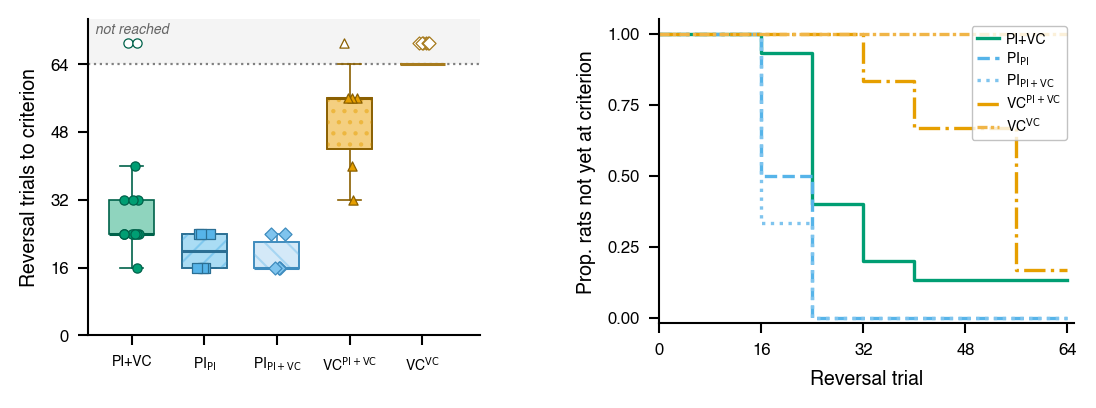

In [9]:
# Preview render: Panel 4B (box & whisker, FIG4B_STYLE) + Kaplan-Meier supporting view
fig = plt.figure(figsize=(5.6, 2.0))
ax_l = fig.add_axes([0.09, 0.13, 0.35, 0.79])
ax_r = fig.add_axes([0.60, 0.16, 0.37, 0.76])
panel_b_ttc(ax_l)
plot_ttc_km(ax_r)
plt.show()

## Statistics — Panel 4D, reversal accuracy

- **Phase 1**: 2×5 mixed ANOVA (block 1 vs 2 within × group between).
- **Phase 2**: 8×5 mixed ANOVA (block within × group between) on the
  carry-forward-completed table (balanced) + Bonferroni post-hocs on the
  block-averaged accuracy.
- **Cue-exposure control** (next section): a focused PI_PI vs PI_PI+VC test.

Uses `pingouin` if available; otherwise falls back to `scipy` for the simple
effects and notes the skipped mixed ANOVA.

### Assumption checks — Phase 1 (standard trials)

Run before the 2 × 5 mixed ANOVA below (block 1 vs 2 within × group between; per-rat accuracy over
the 16 standard trials, 8 per block). With two within-subject levels sphericity is ε = 1 by
definition, so the checks that can bite are: per-cell **normality** (values are k/8 with a strong
block-2 ceiling), normality of the **block-2 − block-1 change score** (with 2 levels the RM effect
*is* the change score), **variance homogeneity** across groups (Levene), and equality of the 2 × 2
covariance matrices (**Box's M**). Welch / rank-based robustness versions were checked in a separate development report
(retired 2026-09-25) and are not reproduced here.

In [10]:
# Assumption checks for the Phase-1 (standard trials) 2x5 mixed ANOVA that follows.
from scipy import stats as sps

_p1 = (rat_full[rat_full['phase'] == 'P1']
       .assign(block=lambda d: d['block'].astype(int), group=lambda d: d['group'].astype(str)))
p1w = (_p1.pivot_table(index=['subject_id', 'group'], columns='block', values='correct')
       .rename(columns={1: 'b1', 2: 'b2'}).reset_index())
p1w['change'] = p1w['b2'] - p1w['b1']

print('=== Phase 1 (standard trials) accuracy: assumption checks for the 2x5 mixed ANOVA ===')

print('\n[1] Cells (per-rat proportions, k/8; note the block-2 ceiling):')
_desc = p1w.groupby('group', observed=True).agg(
    n=('subject_id', 'size'),
    b1_mean=('b1', 'mean'), b1_sd=('b1', 'std'), b1_at_1=('b1', lambda s: int((s == 1).sum())),
    b2_mean=('b2', 'mean'), b2_sd=('b2', 'std'), b2_at_1=('b2', lambda s: int((s == 1).sum())),
    chg_mean=('change', 'mean'), chg_sd=('change', 'std'),
).reindex(GROUP_ORDER).round(3)
print(_desc.to_string())
_ceil = int((p1w['b2'] == 1).sum())
print(f'Rats at 8/8 in block 2: {_ceil}/{len(p1w)} ({100 * _ceil / len(p1w):.0f}%) -> ceiling compresses block-2 variance.')

print('\n[2] Normality (Shapiro-Wilk) per group x block cell and for the change score:')
_rows = []
for g in GROUP_ORDER:
    _sub = p1w[p1w['group'] == g]
    _row = {'group': g}
    for _col, _lab in (('b1', 'block 1'), ('b2', 'block 2'), ('change', 'change b2-b1')):
        _v = _sub[_col].to_numpy(float)
        if len(np.unique(_v)) > 2:
            _W, _pv = sps.shapiro(_v)
            _row[_lab] = f'W={_W:.3f} p={_pv:.3f}' + (' *' if _pv < .05 else '')
        else:
            _row[_lab] = f'({len(np.unique(_v))} distinct value(s))'
    _rows.append(_row)
print(pd.DataFrame(_rows).to_string(index=False))

print('\n[3] Homogeneity of variance across groups (Levene, median-centred):')
for _col, _lab in (('b1', 'block 1'), ('b2', 'block 2'), ('change', 'change score')):
    _grps = [p1w.loc[p1w['group'] == g, _col].to_numpy(float) for g in GROUP_ORDER]
    _lv = sps.levene(*_grps, center='median')
    _sds = [v.std(ddof=1) for v in _grps]
    print(f'  {_lab:12s}: W = {_lv.statistic:5.2f}, p = {_lv.pvalue:.4f}'
          + ('  VIOLATED' if _lv.pvalue < .05 else '  ok')
          + f'   (SD ratio max/min = {max(_sds) / min(_sds):.1f})')

print("\n[4] Box's M (equality of the 2x2 covariance matrices across the 5 groups):")
try:
    import pingouin as _pg
    _bm = _pg.box_m(p1w, dvs=['b1', 'b2'], group='group')
    print(_bm.round(4).to_string())
except Exception as _e:
    print('  box_m unavailable:', _e)

print("\n[5] Sphericity: the within factor has only 2 levels -> eps = 1 by definition; no correction needed.")
print('[6] Design: n = 15/6/6/6/6 (unequal) -> the pooled-error ANOVA leans on the 15-rat group; '
      'Welch and rank-based counterparts were checked in a retired development report; not reproduced here.')

=== Phase 1 (standard trials) accuracy: assumption checks for the 2x5 mixed ANOVA ===

[1] Cells (per-rat proportions, k/8; note the block-2 ceiling):
           n  b1_mean  b1_sd  b1_at_1  b2_mean  b2_sd  b2_at_1  chg_mean  chg_sd
group                                                                           
PI+VC     15    0.783  0.145        2    0.992  0.032       14     0.208   0.154
PI_PI      6    0.688  0.304        2    0.958  0.065        4     0.271   0.310
PI_PI+VC   6    0.542  0.129        0    0.979  0.051        5     0.438   0.153
VC^PI+VC   6    0.792  0.188        1    0.938  0.068        3     0.146   0.166
VC^VC      6    0.854  0.146        2    0.958  0.065        4     0.104   0.146
Rats at 8/8 in block 2: 30/39 (77%) -> ceiling compresses block-2 variance.

[2] Normality (Shapiro-Wilk) per group x block cell and for the change score:
   group         block 1               block 2    change b2-b1
   PI+VC W=0.929 p=0.262 (2 distinct value(s)) W=0.925 p=0.230
 

       Chi2    df   pval  equal_cov
box  13.209  12.0  0.354       True

[5] Sphericity: the within factor has only 2 levels -> eps = 1 by definition; no correction needed.
[6] Design: n = 15/6/6/6/6 (unequal) -> the pooled-error ANOVA leans on the 15-rat group; Welch and rank-based counterparts were checked in a retired development report; not reproduced here.


In [11]:
try:
    import pingouin as pg
    HAS_PG = True
except ImportError:
    HAS_PG = False
    from scipy import stats

# Phase-1 per-rat × block accuracy.
p1 = (rat_full[rat_full['phase'] == 'P1']
      .assign(block=lambda d: d['block'].astype(int))
      [['subject_id', 'group', 'block', 'correct']].copy())

print('=== Phase 1: 2x5 mixed ANOVA (block within x group between) ===')
if HAS_PG:
    aov1 = pg.mixed_anova(data=p1, dv='correct', within='block',
                          between='group', subject='subject_id')
    print(aov1.round(4).to_string(index=False))
else:
    # Fallback: 1-way ANOVA on the block1->block2 change score per rat.
    wide = p1.pivot_table(index=['subject_id', 'group'], columns='block',
                          values='correct')
    wide['delta'] = wide[2] - wide[1]
    groups_data = [g['delta'].values for _, g in wide.reset_index().groupby('group')]
    f, p = stats.f_oneway(*groups_data)
    print(f'pingouin missing; 1-way ANOVA on block1->2 change by group: '
          f'F = {f:.3f}, p = {p:.4g}')

=== Phase 1: 2x5 mixed ANOVA (block within x group between) ===
     Source     SS  DF1  DF2     MS       F  p_unc    np2  eps
      group 0.1836    4   34 0.0459  2.4842 0.0620 0.2262  NaN
      block 1.0098    1   34 1.0098 58.3370 0.0000 0.6318  1.0
Interaction 0.2063    4   34 0.0516  2.9799 0.0327 0.2596  NaN


### Phase 1 — within-group block post-hocs (manuscript values)

The draft quotes the block-1 → block-2 improvement per group ("PI$_{PI+VC}$ rats improved from 54% to 98% (p = .005)"). Paired *t* within each group, Bonferroni over the five groups, with an exact Wilcoxon and the count of improving rats as small-*n* checks.

In [12]:
# Phase-1 within-group block 1 -> block 2 post-hocs (the manuscript's "improved from 54% to 98%
# (p = .005)" values). Paired t per group, Bonferroni over the five groups; exact Wilcoxon and
# the count of rats that improved as small-n checks. NOTE: the PI_PI value the draft quoted as
# "p = .09" is the UNCORRECTED paired-t p (Bonferroni x5 = .43).
from scipy import stats as sps

_p1w = (p1.assign(group=p1['group'].astype(str))
          .pivot_table(index=['subject_id', 'group'], columns='block', values='correct').reset_index())
_rows = []
for g in GROUP_ORDER:
    _s = _p1w[_p1w['group'] == g]
    _a, _b = _s[1].to_numpy(float), _s[2].to_numpy(float)
    _t, _p = sps.ttest_rel(_b, _a)
    _d = _b - _a
    try:
        _w = sps.wilcoxon(_d[_d != 0], method='exact').pvalue
    except ValueError:
        _w = np.nan
    _rows.append({'group': g, 'n': len(_a), 'block 1 %': 100 * _a.mean(), 'block 2 %': 100 * _b.mean(),
                  't': _t, 'df': len(_a) - 1, 'p_unc': _p, 'p_bonf (x5)': min(1.0, 5 * _p),
                  'Wilcoxon p': _w,
                  'improved/worse/tied': f'{int((_d > 0).sum())}/{int((_d < 0).sum())}/{int((_d == 0).sum())}'})
p1_posthoc = pd.DataFrame(_rows)
print('=== Phase 1: block 1 -> block 2 within each group (paired t, Bonferroni x5; exact Wilcoxon) ===')
print(p1_posthoc.round(4).to_string(index=False))


=== Phase 1: block 1 -> block 2 within each group (paired t, Bonferroni x5; exact Wilcoxon) ===
   group  n  block 1 %  block 2 %      t  df  p_unc  p_bonf (x5)  Wilcoxon p improved/worse/tied
   PI+VC 15    78.3333    99.1667 5.2291  14 0.0001       0.0006      0.0005              12/0/3
   PI_PI  6    68.7500    95.8333 2.1372   5 0.0856       0.4281      0.1875               4/1/1
PI_PI+VC  6    54.1667    97.9167 7.0000   5 0.0009       0.0046      0.0312               6/0/0
VC^PI+VC  6    79.1667    93.7500 2.1500   5 0.0842       0.4212      0.1562               5/1/0
   VC^VC  6    85.4167    95.8333 1.7461   5 0.1412       0.7062      0.1875               4/1/1


### Assumption checks — Phase 2 (reversal trials)

Same pattern as the Phase-1 cell, for the 8 × 5 imputed ANOVA below: per-cell normality /
discreteness, per-block Levene, Mauchly's test + GG ε, the imputation share and the k/8 scale.
Defines the shared `mixed_assumptions` helper, reused for Panels E & F.

In [13]:
# Shared assumption-check helper for the block x group mixed ANOVAs (Phase-2 accuracy here;
# reused for Panels E & F). pingouin's Mauchly / epsilon pool the TOTAL covariance ignoring
# group; afex's within-group pooling was checked in a retired development report.
from scipy import stats as sps

def mixed_assumptions(rt, value, label, k_blocks=8, phases=('P1', 'P2'), extremes=None, skew_note=False):
    """Assumption checks for the P1 2x5 and/or P2 (blocks 1..k, listwise-complete rats,
    matching fig4b_stats) block x group mixed ANOVAs on one per-rat x phase x block table."""
    d = rt[['subject_id', 'group', 'phase', 'block', value]].dropna().copy()
    d['group'] = d['group'].astype(str)
    d['block'] = d['block'].astype(int)
    d[value] = d[value].astype(float)
    print('=' * 88 + f'\n{label}\n' + '=' * 88)

    if 'P1' in phases:
        w = (d[d['phase'] == 'P1'].pivot_table(index=['subject_id', 'group'], columns='block', values=value)
             .rename(columns={1: 'b1', 2: 'b2'}).reset_index())
        w['change'] = w['b2'] - w['b1']
        print('\n[P1] group x block cells and the block2 - block1 change score '
              '(2 within levels -> the RM effect IS the change score; sphericity eps = 1):')
        _rows = []
        for g in GROUP_ORDER:
            sub = w[w['group'] == g]
            row = {'group': g, 'n': len(sub)}
            for col in ('b1', 'b2', 'change'):
                v = sub[col].to_numpy(float)
                cell = f'{v.mean():.3f} ({v.std(ddof=1):.3f})'
                if len(np.unique(v)) > 2:
                    cell += f', Shapiro p={sps.shapiro(v).pvalue:.3f}' + ('*' if sps.shapiro(v).pvalue < .05 else '')
                else:
                    cell += f', {len(np.unique(v))} distinct'
                row[col] = cell
            _rows.append(row)
        print(pd.DataFrame(_rows).to_string(index=False))
        for col, lab in (('b1', 'block 1'), ('b2', 'block 2'), ('change', 'change')):
            grps = [w.loc[w['group'] == g, col].to_numpy(float) for g in GROUP_ORDER]
            try:
                lv = sps.levene(*grps, center='median')
                print(f'     Levene {lab:8s}: W = {lv.statistic:5.2f}, p = {lv.pvalue:.4f}'
                      + ('  VIOLATED' if lv.pvalue < .05 else '  ok'))
            except Exception:
                print(f'     Levene {lab:8s}: not computable (zero spread in a group)')
        if HAS_PG:
            try:
                bm = pg.box_m(w, dvs=['b1', 'b2'], group='group')
                print(f"     Box's M (2x2 covariances): Chi2({int(bm['df'].iloc[0])}) = "
                      f"{float(bm['Chi2'].iloc[0]):.2f}, p = {float(bm['pval'].iloc[0]):.4f}")
            except Exception as e:
                print("     Box's M unavailable:", e)

    if 'P2' in phases:
        p2 = d[(d['phase'] == 'P2') & (d['block'] <= k_blocks)]
        nblk = p2.groupby('subject_id')['block'].nunique()
        p2c = p2[p2['subject_id'].isin(nblk[nblk == k_blocks].index)]
        kept = p2c.groupby('group')['subject_id'].nunique().reindex(GROUP_ORDER).fillna(0).astype(int)
        print(f'\n[P2] blocks 1-{k_blocks} x 5 groups, listwise-complete rats: '
              + ' / '.join(f'{g} {n}' for g, n in kept.items()) + f' = {int(kept.sum())} of {d["subject_id"].nunique()}')
        n_cells = const = rej = testable = 0
        for g in GROUP_ORDER:
            for b in range(1, k_blocks + 1):
                v = p2c[(p2c['group'] == g) & (p2c['block'] == b)][value].to_numpy(float)
                if len(v) == 0:
                    continue
                n_cells += 1
                if len(np.unique(v)) == 1:
                    const += 1
                elif len(np.unique(v)) > 2 and len(v) >= 3:
                    testable += 1
                    rej += int(sps.shapiro(v).pvalue < .05)
        print(f'     Normality per cell: {rej}/{testable} testable cells rejected (Shapiro p < .05); '
              f'{const}/{n_cells} cells constant.')
        for b in range(1, k_blocks + 1):
            grps = [p2c[(p2c['group'] == g) & (p2c['block'] == b)][value].to_numpy(float) for g in GROUP_ORDER]
            grps = [v for v in grps if len(v) > 1]
            try:
                lv = sps.levene(*grps, center='median')
                print(f'     Levene block {b}: W = {lv.statistic:5.2f}, p = {lv.pvalue:.4f}'
                      + ('  VIOLATED' if lv.pvalue < .05 else '  ok'))
            except Exception:
                print(f'     Levene block {b}: not computable (zero spread)')
        if HAS_PG and k_blocks > 2:
            spher = pg.sphericity(p2c, dv=value, within='block', subject='subject_id')
            eps = pg.epsilon(p2c, dv=value, within='block', subject='subject_id', correction='gg')
            print(f"     Mauchly: W = {spher.W:.4g}, chi2({int(spher.dof)}) = {spher.chi2:.1f}, "
                  f"p = {spher.pval:.3g} -> {'VIOLATED, report GG df' if spher.pval < .05 else 'not rejected'}; "
                  f"eps_GG = {eps:.3f}")
        if 'imputed' in rt.columns:
            m = rt[(rt['phase'] == 'P2') & (rt['block'] <= k_blocks)]
            print(f"     Imputation: {int(m['imputed'].sum())}/{len(m)} window rat-blocks are carry-forward values.")
        if extremes is not None:
            lo, hi = extremes
            v = p2c[value].to_numpy(float)
            print(f'     Scale: k/8 proportions; {100 * np.mean(v == lo):.0f}% of window rat-blocks at {lo:g}, '
                  f'{100 * np.mean(v == hi):.0f}% at {hi:g}.')
        if skew_note:
            v = p2c[value].to_numpy(float)
            print(f'     Skew of window scores: {sps.skew(v, bias=False):+.2f} '
                  f'(right-skewed latency; log / rank / per-rat-median robustness were checked in a retired development report).')

mixed_assumptions(rat_full, 'correct',
                  'ACCURACY (Panel D) -- Phase-2 assumption checks for the 8x5 mixed ANOVA below (imputed table)',
                  k_blocks=8, phases=('P2',), extremes=(0.0, 1.0))

ACCURACY (Panel D) -- Phase-2 assumption checks for the 8x5 mixed ANOVA below (imputed table)

[P2] blocks 1-8 x 5 groups, listwise-complete rats: PI+VC 15 / PI_PI 6 / PI_PI+VC 6 / VC^PI+VC 6 / VC^VC 6 = 39 of 39
     Normality per cell: 13/20 testable cells rejected (Shapiro p < .05); 13/40 cells constant.
     Levene block 1: W =  7.16, p = 0.0003  VIOLATED
     Levene block 2: W =  1.50, p = 0.2232  ok
     Levene block 3: W =  1.53, p = 0.2149  ok
     Levene block 4: W =  1.11, p = 0.3663  ok
     Levene block 5: W =  1.56, p = 0.2074  ok
     Levene block 6: W =  0.72, p = 0.5837  ok
     Levene block 7: W =  0.61, p = 0.6588  ok
     Levene block 8: W =  0.62, p = 0.6542  ok
     Mauchly: W = 0.0002429, chi2(27) = 295.1, p = 1.89e-46 -> VIOLATED, report GG df; eps_GG = 0.331
     Imputation: 96/312 window rat-blocks are carry-forward values.
     Scale: k/8 proportions; 17% of window rat-blocks at 0, 53% at 1.


In [14]:
# Phase-2 per-rat × block accuracy (carry-forward completed -> balanced).
p2 = (rat_full[rat_full['phase'] == 'P2']
      .assign(block=lambda d: d['block'].astype(int))
      [['subject_id', 'group', 'block', 'correct']].copy())

print('=== Phase 2: 8x5 mixed ANOVA (block within x group between) ===')
if HAS_PG:
    aov2 = pg.mixed_anova(data=p2, dv='correct', within='block',
                          between='group', subject='subject_id')
    print(aov2.round(4).to_string(index=False))
    print('\n=== Bonferroni post-hocs: group main effect (block-averaged) ===')
    avg = (p2.groupby(['subject_id', 'group'], observed=True)['correct']
             .mean().reset_index())
    ph = pg.pairwise_tests(data=avg, dv='correct', between='group', padjust='bonf')
    print(ph.round(4).to_string(index=False))
else:
    avg = (p2.groupby(['subject_id', 'group'], observed=True)['correct']
             .mean().reset_index())
    groups_data = [g['correct'].values for _, g in avg.groupby('group')]
    f, p = stats.f_oneway(*groups_data)
    print(f'pingouin missing; 1-way ANOVA on block-averaged P2 accuracy: '
          f'F = {f:.3f}, p = {p:.4g}  (mixed ANOVA skipped — `pip install pingouin`)')

=== Phase 2: 8x5 mixed ANOVA (block within x group between) ===
     Source      SS  DF1  DF2     MS        F  p_unc  p_GG_corr    np2   eps sphericity  W_spher  p_spher
      group 24.0332    4   34 6.0083  32.6790    0.0        NaN 0.7936   NaN        NaN      NaN      NaN
      block 15.0278    7  238 2.1468 118.7421    0.0        0.0 0.7774 0.331      False   0.0002      0.0
Interaction  4.4231   28  238 0.1580   8.7372    0.0        NaN 0.5069   NaN        NaN      NaN      NaN

=== Bonferroni post-hocs: group main effect (block-averaged) ===


Contrast        A        B  Paired  Parametric       T     dof alternative  p_unc  p_corr p_adjust      BF10  hedges
   group    PI+VC    PI_PI   False        True -3.2776 16.3916   two-sided 0.0046  0.0462     bonf     9.957 -0.9841
   group    PI+VC PI_PI+VC   False        True -2.9805 17.7677   two-sided 0.0081  0.0810     bonf      6.12 -0.9207
   group    PI+VC VC^PI+VC   False        True  1.8860  9.2205   two-sided 0.0911  0.9114     bonf     1.326  0.8769
   group    PI+VC    VC^VC   False        True 12.1994 17.5071   two-sided 0.0000  0.0000     bonf 2.411e+07  3.7453
   group    PI_PI PI_PI+VC   False        True  0.3930 10.0000   two-sided 0.7026  1.0000     bonf     0.491  0.2094
   group    PI_PI VC^PI+VC   False        True  4.3044 10.0000   two-sided 0.0016  0.0155     bonf    20.174  2.2940
   group    PI_PI    VC^VC   False        True 32.9988 10.0000   two-sided 0.0000  0.0000     bonf 1.678e+08 17.5863
   group PI_PI+VC VC^PI+VC   False        True  4.1190 10.0000  

### Phase 2 — afex Type III with Greenhouse–Geisser (manuscript values)

Sphericity is violated (Mauchly above), so the manuscript reports Greenhouse–Geisser df. As for Figs 2 and 3, the cited values come from `afex::aov_ez` (Type III; ε from the pooled within-group covariance, as SPSS/car compute it), not from pingouin's total-covariance ε.

In [15]:
# Greenhouse-Geisser for the 8 x 5 Phase-2 ANOVA via R's afex::aov_ez (Type III; epsilon from the
# pooled within-group covariance, as SPSS/car do) -- the values the manuscript cites, as for
# Figs 2 and 3. pingouin's `eps` above (0.33) comes from the TOTAL subject x block covariance
# (group mean differences included), so it runs low when there is a block x group interaction.
# With unequal groups (15/6/6/6/6) the BLOCK main-effect F also differs: pingouin weights the
# groups by n, afex Type III uses unweighted group means; group and interaction F are identical.
from rpy2.robjects import r, pandas2ri, globalenv, default_converter
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr

importr('afex')
with localconverter(default_converter + pandas2ri.converter):
    _r_df = p2[['subject_id', 'group', 'block', 'correct']].copy()
    _r_df['subject_id'] = _r_df['subject_id'].astype(str)
    _r_df['group'] = _r_df['group'].astype(str)
    _r_df['block'] = _r_df['block'].astype(str)
    globalenv['df_f4d'] = _r_df
    aov2_afex = r(f"""
    df_f4d$subject_id <- factor(df_f4d$subject_id)
    df_f4d$group <- factor(df_f4d$group, levels = c({', '.join(repr(g) for g in GROUP_ORDER)}))
    df_f4d$block <- factor(df_f4d$block, levels = as.character(1:8))
    fit_f4d <- afex::aov_ez(id = 'subject_id', dv = 'correct', within = 'block', between = 'group',
                            data = df_f4d, anova_table = list(correction = 'GG', es = 'pes'))
    fit_f4d$anova_table
    """)
    aov2_afex_unc = r("as.data.frame(anova(fit_f4d, correction = 'none', es = 'pes'))")
    aov2_sph = r("{ s <- summary(fit_f4d); m <- s$sphericity.tests; e <- s$pval.adjustments; "
                 "data.frame(term = rownames(m), W = as.numeric(m[, 1]), p = as.numeric(m[, 2]), "
                 "eps_GG = as.numeric(e[, 1]), eps_HF = as.numeric(e[, 3])) }")

print('=== Phase 2: 8x5 mixed ANOVA, afex::aov_ez Type III, Greenhouse-Geisser (the manuscript values) ===')
print(aov2_afex.round(4).to_string())
print('\nUncorrected df, for reference:')
print(aov2_afex_unc.round(4).to_string())
print('\nMauchly / epsilon (pooled within-group covariance):')
print(aov2_sph.round(4).to_string(index=False))

# afex and pingouin must agree on the group and interaction F; only the block F differs (see above).
_pg_F = aov2.set_index('Source')['F']
assert abs(aov2_afex.loc['group', 'F'] - _pg_F['group']) < 1e-3
assert abs(aov2_afex.loc['group:block', 'F'] - _pg_F['Interaction']) < 1e-3
print(f"\nCheck: group F {aov2_afex.loc['group', 'F']:.2f} and group:block F {aov2_afex.loc['group:block', 'F']:.2f} "
      f"equal pingouin; block F {aov2_afex.loc['block', 'F']:.2f} (afex, unweighted group means) vs "
      f"{_pg_F['block']:.2f} (pingouin, n-weighted).")

# Block-averaged Phase-2 accuracy per group: the quantity the Bonferroni post-hocs above compare
# (the manuscript's "mean Phase 2 accuracy (6%)" for VC^VC).
print('\nBlock-averaged Phase-2 accuracy (%), per-rat means by group:')
_avg_tab = (avg.assign(group=avg['group'].astype(str)).groupby('group')['correct']
            .agg(['count', 'mean', 'std', 'sem']).reindex(GROUP_ORDER))
_avg_tab[['mean', 'std', 'sem']] *= 100
print(_avg_tab.round(2).to_string())


R callback write-console: Contrasts set to contr.sum for the following variables: group
  


=== Phase 2: 8x5 mixed ANOVA, afex::aov_ez Type III, Greenhouse-Geisser (the manuscript values) ===
              num Df   den Df     MSE        F     pes  Pr(>F)
group         4.0000  34.0000  0.1839  32.6790  0.7936     0.0
block         2.7465  93.3813  0.0461  84.8663  0.7140     0.0
group:block  10.9860  93.3813  0.0461   8.7372  0.5069     0.0

Uncorrected df, for reference:
             num Df  den Df     MSE        F     pes  Pr(>F)
group           4.0    34.0  0.1839  32.6790  0.7936     0.0
block           7.0   238.0  0.0181  84.8663  0.7140     0.0
group:block    28.0   238.0  0.0181   8.7372  0.5069     0.0

Mauchly / epsilon (pooled within-group covariance):
       term      W   p  eps_GG  eps_HF
      block 0.0019 0.0  0.3924  0.4303
group:block 0.0019 0.0  0.3924  0.4303

Check: group F 32.68 and group:block F 8.74 equal pingouin; block F 84.87 (afex, unweighted group means) vs 118.74 (pingouin, n-weighted).

Block-averaged Phase-2 accuracy (%), per-rat means by group:


## Cue-exposure control — did prior Novel-Route cue exposure affect reversal?

All PI rats reverse *without* a cue, but half saw a cue during the earlier
Novel-Route probe (`PI_PI+VC`) and half did not (`PI_PI`). A direct
PI_PI vs PI_PI+VC comparison on the reversal curves tests whether that prior
exposure carried over. Result: it did **not** — near-identical curves, no
subgroup main effect, and a Bayes factor favouring the null.

In [16]:
pi_sub = rat_full[rat_full['group'].astype('string').isin(['PI_PI', 'PI_PI+VC'])].copy()
pi_sub['group'] = pi_sub['group'].astype('string')
p2_pi = (pi_sub[pi_sub['phase'] == 'P2']
         .assign(block=lambda d: d['block'].astype(int))
         [['subject_id', 'group', 'block', 'correct']])

print('PI_PI vs PI_PI+VC — Phase-2 reversal accuracy by block (%):')
print((p2_pi.groupby(['group', 'block'])['correct'].mean() * 100)
      .unstack().round(1).to_string())

if HAS_PG:
    aov_pi = pg.mixed_anova(data=p2_pi, dv='correct', within='block',
                            between='group', subject='subject_id')
    print('\n=== Phase 2: 8x2 mixed ANOVA (block within x PI-subgroup between) ===')
    print(aov_pi.round(4).to_string(index=False))

    avg_pi = (p2_pi.groupby(['subject_id', 'group'], observed=True)['correct']
                   .mean().reset_index())
    tt = pg.pairwise_tests(data=avg_pi, dv='correct', between='group')
    print('\nBlock-averaged PI_PI vs PI_PI+VC (with Bayes factor):')
    print(tt.round(4).to_string(index=False))

    pcol = 'p-unc' if 'p-unc' in aov_pi.columns else 'p_unc'
    grp_p = float(aov_pi.loc[aov_pi['Source'] == 'group', pcol].iloc[0])
    bf = tt['BF10'].iloc[0]
    print(f'\n=> Prior Novel-Route cue exposure did NOT affect reversal: '
          f'subgroup p = {grp_p:.3f}, BF10 = {bf} (BF10 < 1 => evidence for '
          f'no difference).')
else:
    avg_pi = (p2_pi.groupby(['subject_id', 'group'], observed=True)['correct']
                   .mean().reset_index())
    a = avg_pi.loc[avg_pi['group'] == 'PI_PI', 'correct']
    b = avg_pi.loc[avg_pi['group'] == 'PI_PI+VC', 'correct']
    f, p = stats.f_oneway(a, b)
    print(f'\npingouin missing; block-averaged PI_PI vs PI_PI+VC: '
          f'F = {f:.3f}, p = {p:.4g}')

PI_PI vs PI_PI+VC — Phase-2 reversal accuracy by block (%):
block        1     2      3      4      5      6      7      8
group                                                         
PI_PI     35.4  91.7  100.0  100.0  100.0  100.0  100.0  100.0
PI_PI+VC  33.3  85.4  100.0  100.0  100.0  100.0  100.0  100.0

=== Phase 2: 8x2 mixed ANOVA (block within x PI-subgroup between) ===
     Source     SS  DF1  DF2     MS       F  p_unc    np2    eps
      group 0.0026    1   10 0.0026  0.1544 0.7026 0.0152    NaN
      block 4.4342    7   70 0.6335 55.0606 0.0000 0.8463 0.2396
Interaction 0.0104    7   70 0.0015  0.1293 0.9959 0.0128    NaN

Block-averaged PI_PI vs PI_PI+VC (with Bayes factor):
Contrast     A        B  Paired  Parametric     T  dof alternative  p_unc  BF10  hedges
   group PI_PI PI_PI+VC   False        True 0.393 10.0   two-sided 0.7026 0.491  0.2094

=> Prior Novel-Route cue exposure did NOT affect reversal: subgroup p = 0.703, BF10 = 0.491 (BF10 < 1 => evidence for no diff

## Panel 4D — reversal accuracy (group × block)

Panels E and F reuse `panel_b_accuracy` with their own aggregates and y-axis knobs (the panel functions keep their historical letter names: `panel_b_accuracy`, `panel_c_perseveration`, `panel_d_latency`).

In [17]:
def panel_b_accuracy(ax, *, group_acc=group_acc,
                     line_lw=1.2,
                     marker_size=STYLE_CFG['marker_size'],
                     marker_edge_lw=STYLE_CFG['marker_edge_lw'],
                     err_lw=STYLE_CFG['err_lw'],
                     cap_size=STYLE_CFG['cap_size'],
                     group_offset=0.07,
                     show_criterion=True, criterion_y=0.8,
                     axhline_lw=STYLE_CFG['axhline_lw'],
                     ylim=(-0.025, 1.05),
                     yticks=(0, 0.25, 0.5, 0.75, 1.0),
                     ylabel='% correct trials',
                     xlabel='Trial block',
                     xlabel_pad=13,
                     x_margin=0.6,          # x-units of padding beyond the outermost ticks
                     show_ylabel=True,
                     show_phase_labels=True,   # small grey 'Phase 1' / 'Phase 2' (unsplit layout only)
                     phase_label_y=-0.12,
                     # --- Phase 1 | Phase 2 split (same machinery as figure3 Panel B) ---
                     split_phases=False,    # True: P1 blocks 1-2 and P2 blocks 1-8 on two axes sharing one y-axis
                     split_at=1.5,          # x (data units) where the axis breaks (the old dashed line)
                     split_gap=0.5,         # width of the break in x-units (0.5 = half a tick spacing)
                     split_xlabels=('Phase 1\ntrial block', 'Phase 2\ntrial block'),  # x-titles of the left / right axes
                     split_right_spine=False,  # draw the right axes' left spine
                     pane_titles=None,      # e.g. ('Standard trials', 'Reversal trials'): one title centred over each pane
                     title_fontsize=None,   # None = rcParams['axes.titlesize']
                     title_pad=3,           # pt between the axes top and the titles
                     show_legend=True, legend_loc='lower right',
                     legend_fontsize=5, legend_frameon=True,
                     legend_frame_lw=STYLE_CFG['legend_frame_lw'],
                     legend_ncol=1, legend_bbox=None):
    sub = group_acc.copy()
    x_orders = sorted(sub['x_order'].unique())
    xmin, xmax = min(x_orders) - x_margin, max(x_orders) + x_margin

    if split_phases:
        # Two axes sharing the y-axis: Phase 1 (blocks 1-2) on the left, Phase 2
        # (blocks 1-8) on the right. The break is cut OUT of the existing axes
        # footprint (centred on `split_at`), so the x-scale (inches per x-unit)
        # and the panel's overall width are unchanged.
        fig = ax.figure
        bx = ax.get_position()
        unit = bx.width / (xmax - xmin)
        l_x1 = split_at - split_gap / 2
        r_x0 = split_at + split_gap / 2
        ax.set_position([bx.x0, bx.y0, (l_x1 - xmin) * unit, bx.height])
        ax_r = fig.add_axes([bx.x0 + (r_x0 - xmin) * unit, bx.y0,
                             (xmax - r_x0) * unit, bx.height])
        panes = [(ax, (xmin, l_x1), split_xlabels[0]),
                 (ax_r, (r_x0, xmax), split_xlabels[1])]
        ax.right_pane = ax_r   # handle for callers (legend/annotation tweaks)
    else:
        panes = [(ax, (xmin, xmax), xlabel)]

    n_groups = len(GROUP_ORDER)
    # Every pane draws the full data set and is clipped by its own xlim
    for pane, (px0, px1), pane_xlabel in panes:
        if show_criterion:
            pane.axhline(criterion_y, lw=axhline_lw, ls=':', color='0.5', zorder=0)
        for i, group in enumerate(GROUP_ORDER):
            g_sub = sub[sub['group'] == group].sort_values('x_order')
            if g_sub.empty:
                continue
            style = STYLE[group]
            offset = (i - (n_groups - 1) / 2) * group_offset
            xs = np.asarray(g_sub['x_order'].values, dtype=float) + offset
            means = np.asarray(g_sub['mean'].values, dtype=float)
            sems = g_sub['sem'].fillna(0).values
            # Break the connecting line between Phase 1 (x_order 0-1) and
            # Phase 2 (x_order 2-9): they are separate task conditions.
            split = int((g_sub['x_order'] <= 1).sum())
            if 0 < split < len(xs):
                xs = np.insert(xs, split, np.nan)
                means = np.insert(means, split, np.nan)
                sems = np.insert(sems, split, 0.0)
            pane.errorbar(
                xs, means, yerr=sems,
                fmt=style['marker'], ls=style['line'],
                color=style['base'],
                markerfacecolor=style['base'],
                markeredgecolor=style['edge'],
                markeredgewidth=marker_edge_lw,
                markersize=marker_size,
                lw=line_lw, ecolor=style['edge'],
                elinewidth=err_lw, capsize=cap_size, capthick=err_lw,
                label=GROUP_LABELS[group], zorder=3,
            )

        pane_ticks = [o for o in x_orders if px0 <= o <= px1]
        pane.set_xticks(pane_ticks)
        pane.set_xticklabels([XORDER_LABEL[o] for o in pane_ticks])
        if not split_phases:
            # Separator between Phase 1 and Phase 2 (single-axes layout).
            pane.axvline(split_at, color='0.7', lw=0.5, ls='--', zorder=0)
        pane.set_xlim(px0, px1)
        pane.set_ylim(*ylim)
        pane.set_yticks(yticks)
        if split_phases:
            pane.set_xlabel(pane_xlabel)
        else:
            # Push the axis title below the per-phase annotations.
            pane.set_xlabel(pane_xlabel, labelpad=xlabel_pad)
        for sp in ('top', 'right'):
            pane.spines[sp].set_visible(False)

    if show_ylabel:
        ax.set_ylabel(ylabel)
    if split_phases:
        # The right pane shares the left pane's y-axis: no ticks/labels of its own
        ax_r.tick_params(axis='y', left=False, labelleft=False)
        ax_r.spines['left'].set_visible(split_right_spine)

    if pane_titles is not None:
        # Titles are placed in figure coords (fig.text), centred over each pane's
        # axes box, so they stay put regardless of tick/label extents.
        y_top = ax.get_position().y1 + title_pad / 72 / ax.figure.get_figheight()
        for (pane, _, _), t in zip(panes, pane_titles):
            if not t:
                continue
            pbox = pane.get_position()
            ax.figure.text((pbox.x0 + pbox.x1) / 2, y_top, t, ha='center', va='bottom',
                           fontsize=title_fontsize or plt.rcParams['axes.titlesize'])

    if show_phase_labels and not split_phases:
        # x in data coords, y in axes-fraction (just under the tick labels,
        # above the xlabel).
        trans = ax.get_xaxis_transform()
        ax.text(0.5, phase_label_y, 'Phase 1', transform=trans, ha='center',
                va='top', fontsize=5.5, color='0.3', clip_on=False)
        ax.text(5.5, phase_label_y, 'Phase 2', transform=trans, ha='center',
                va='top', fontsize=5.5, color='0.3', clip_on=False)

    if show_legend:
        handles = []
        for group in GROUP_ORDER:
            style = STYLE[group]
            handles.append(plt.Line2D(
                [0], [0], color=style['base'], ls=style['line'],
                marker=style['marker'], markerfacecolor=style['base'],
                markeredgecolor=style['edge'], markeredgewidth=marker_edge_lw,
                markersize=marker_size, lw=line_lw, label=GROUP_LABELS[group],
            ))
        kwargs = dict(loc=legend_loc, frameon=legend_frameon,
                      handletextpad=0.5, borderpad=0.4, labelspacing=0.3,
                      ncol=legend_ncol, fontsize=legend_fontsize)
        if legend_bbox is not None:
            kwargs['bbox_to_anchor'] = legend_bbox
        leg = panes[-1][0].legend(handles=handles, **kwargs)   # legend lives on the right pane when split
        if legend_frameon:
            frame = leg.get_frame()
            frame.set_linewidth(legend_frame_lw)
            frame.set_edgecolor('0.7')
            frame.set_facecolor('white')
    return ax

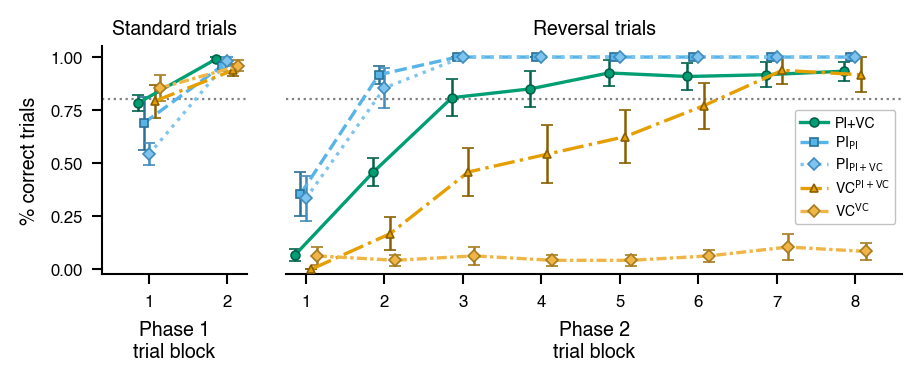

In [18]:
# Preview render: Panel 4D (reversal accuracy)
fig = plt.figure(figsize=(4.6, 1.9))
ax = fig.add_axes([0.10, 0.29, 0.87, 0.60])   # fixed rect: tight_layout would misalign the split panes; top at 0.89 leaves room for the pane titles
# Legend in the empty band between the VC^VC curve and the high plateau:
# bottom edge anchored at axes-frac 0.15 (5 entries need the extra headroom).
panel_b_accuracy(ax, split_phases=True,
                 pane_titles=('Standard trials', 'Reversal trials'),
                 show_legend=True, legend_loc='lower right',
                 legend_bbox=(1.0, 0.19))
plt.show()

## Panels E & F metrics — perseveration and latency

**Metric 1 — reversal perseveration ("% pre-reversal responses").** At the reversal the goal
jumps to the opposite corner (trial 17); geometrically this **flips the correct 1st turn and keeps
the 2nd**. So the *old* (pre-reversal-correct) response is scored from the executed 1st turn:

> `perseverative ⇔ coord_turn_1 == old_first_turn`, where `old_first_turn = correct_route[0]`
> in Phase 1 and `flip(correct_route[0])` in Phase 2 (`flip`: L↔R).

`coord_turn_1` and `correct_route` are both egocentric / frame-invariant, so this works for the
rotating-frame VC$^{\mathrm{VC}}$ group with no special-casing. Chance = 50%. (Mirror of the
Fig 3 novel-route perseveration, which keys on the 2nd turn — do not reuse
`features/perseveration.py` here.)

**Metric 2 — latency to first well entry.** `trials.first_choice_latency_s` (seconds): time from
trial onset (doors open) to the **first well visited, reward or error** (`stage3c_well_visits.py`;
the column name says "choice" but it is first-*well* latency).

**Early stopping.** Fast rats reach criterion and stop, so late Phase-2 blocks keep only the
slower rats. Perseveration is **criterion-imputed** by default: a rat that stopped early is scored
**0 %** perseveration for its remaining Phase-2 blocks — the mirror of Panel D's accuracy
carry-forward of 100 % (a rat at criterion is running the *new* response). This gives full
8-block curves and a balanced 8 × 5 design. Latency has no principled constant to impute, so
Panel F keeps the declining n and hides a group's block once fewer than `LAT_MIN_N` rats ran it.

In [19]:
# --- Metric 1: reversal perseveration ("% pre-reversal responses") ----------
# Executed 1st turn == the OLD (pre-reversal-correct) 1st turn. Reversal flips
# the 1st turn and keeps the 2nd, so old_first = correct_route[0] in P1 and its
# L<->R flip in P2. Frame-invariant, so it also works for the rotating VC^VC group.
FLIP = {'L': 'R', 'R': 'L'}
_cr = probe['correct_route'].astype('string')
_ct1 = probe['coord_turn_1'].astype('string')
_old_first = _cr.str[0].where(probe['phase'].eq('P1'), _cr.str[0].map(FLIP).astype('string'))
probe['persev'] = (_ct1 == _old_first).astype('float64')          # 1 = old response
probe.loc[_ct1.isna() | _old_first.isna(), 'persev'] = np.nan     # NA where turn/route NA

# --- Metric 2: latency to first well entry (reward or error), seconds -------
probe['latency_s'] = probe['first_choice_latency_s'].astype('float64')

print('NA %: persev = {:.2f}   latency_s = {:.2f}   (of {} reversal-probe trials)'.format(
    probe['persev'].isna().mean() * 100, probe['latency_s'].isna().mean() * 100, len(probe)))
print(f"latency_s: trial-level median = {probe['latency_s'].median():.2f} s, "
      f"IQR = {probe['latency_s'].quantile(0.25):.2f}–{probe['latency_s'].quantile(0.75):.2f} s, "
      f"max = {probe['latency_s'].max():.1f} s  (right-skewed -> median scores analysed too)")

# Sanity: in Phase 2 the old 1st turn leads to the old (now empty) goal side, so
# perseverative trials should be errors and non-perseverative trials correct.
_p2 = probe[probe['phase'] == 'P2']
print('\nPhase 2: perseverative (rows) x correct (cols) trial counts:')
print(pd.crosstab(_p2['persev'].map({1.0: 'old response', 0.0: 'new response'}),
                  _p2['correct'].map({1: 'correct', 0: 'error'})).to_string())
print('\nPhase 1 baseline: % pre-reversal (= trained, correct) responses by group x block:')
print((probe[probe['phase'] == 'P1'].groupby(['group', 'block'], observed=True)['persev']
       .mean().unstack() * 100).round(1).to_string())

NA %: persev = 0.00   latency_s = 0.00   (of 2327 reversal-probe trials)
latency_s: trial-level median = 4.40 s, IQR = 3.90–5.06 s, max = 27.7 s  (right-skewed -> median scores analysed too)

Phase 2: perseverative (rows) x correct (cols) trial counts:
correct       correct  error
persev                      
new response      778     23
old response       63    839

Phase 1 baseline: % pre-reversal (= trained, correct) responses by group x block:
block        1     2
group               
PI+VC     83.3  99.2
PI_PI     75.0  95.8
PI_PI+VC  56.2  91.7
VC^PI+VC  93.8  97.9
VC^VC     83.3  93.8


## Shared statistics machinery — the Panel-D tests (`fig4b_stats`)

`fig4b_stats(rt, value, ...)` reproduces the Panel-D (reversal accuracy) analysis for one
per-rat × block table:

1. **Phase 1**: 2 × 5 mixed ANOVA (block within × group between).
2. **Phase 2**: block × group mixed ANOVA + Bonferroni post-hocs on the block-averaged score.
   Perseveration uses the criterion-imputed table (balanced 8 × 5, as Panel D). Latency is not
   imputed and `pingouin.mixed_anova` drops any rat with a missing block (listwise), so the
   latency ANOVA runs on Phase-2 blocks 1–`LAT_P2_BLOCKS` (default 3: 40 of 41 rats complete).
3. **Cue-exposure control**: PI$_{\mathrm{PI}}$ vs PI$_{\mathrm{PI+VC}}$ — block × subgroup mixed
   ANOVA and the block-averaged comparison with its Bayes factor.

Each panel section below runs its aggregation, assumption checks, then this battery, then builds
its panel; the headline p-values collect in `SUMMARY` (tabulated after Panel F).

In [20]:
# ============================ knob ===========================================
LAT_P2_BLOCKS = 3   # Phase-2 window (blocks 1..K) for the latency mixed ANOVA + post-hocs;
                    # rats without all K blocks are dropped (listwise), see the printed counts
# =============================================================================

def _pcol(df, *names):
    """First of `names` that is a column (pingouin renamed p-unc -> p_unc in 0.6)."""
    for n in names:
        if n in df.columns:
            return n
    raise KeyError(names)

def _src_p(aov, source):
    return float(aov.loc[aov['Source'] == source, _pcol(aov, 'p_unc', 'p-unc')].iloc[0])

def fig4b_stats(rt, value, label, p2_blocks=8):
    """The Fig 4B statistics (cells above) on one per-rat x phase x block table
    (subject_id, group, phase, block, value). Prints the tables; returns a dict of
    headline p-values (one SUMMARY row)."""
    res = {'analysis': label}
    d = rt[['subject_id', 'group', 'phase', 'block', value]].dropna().copy()
    d['group'] = d['group'].astype(str)
    d['block'] = d['block'].astype(int)
    d[value] = d[value].astype(float)
    scale = 100 if value == 'persev' else 1          # tables in % for perseveration
    print('\n' + '=' * 90 + f'\n{label}\n' + '=' * 90)
    if not HAS_PG:
        print('pingouin missing; the Fig 4B mixed ANOVAs need `pip install pingouin`.')
        return res

    # --- Phase 1: 2x5 mixed ANOVA (block within x group between) -------------
    p1 = d[d['phase'] == 'P1']
    aov1 = pg.mixed_anova(data=p1, dv=value, within='block', between='group', subject='subject_id')
    print('\n=== Phase 1: 2x5 mixed ANOVA (block within x group between) ===')
    print(aov1.round(4).to_string(index=False))
    res['P1 group'] = _src_p(aov1, 'group')
    res['P1 blk×grp'] = _src_p(aov1, 'Interaction')

    # --- Phase 2: Kx5 mixed ANOVA on rats with all K blocks (listwise) --------
    p2 = d[(d['phase'] == 'P2') & (d['block'] <= p2_blocks)]
    nblk = p2.groupby('subject_id')['block'].nunique()
    p2c = p2[p2['subject_id'].isin(nblk[nblk == p2_blocks].index)]
    kept = p2c.groupby('group')['subject_id'].nunique().reindex(GROUP_ORDER).fillna(0).astype(int)
    print(f'\n=== Phase 2: {p2_blocks}x5 mixed ANOVA (block within x group between) ===')
    print(f'Rats with all {p2_blocks} Phase-2 blocks (listwise-complete): '
          + ', '.join(f'{g} {n}' for g, n in kept.items())
          + f'  = {int(kept.sum())} of {d["subject_id"].nunique()}')
    aov2 = pg.mixed_anova(data=p2c, dv=value, within='block', between='group', subject='subject_id')
    print(aov2.round(4).to_string(index=False))
    res['P2 group'] = _src_p(aov2, 'group')
    res['P2 block'] = _src_p(aov2, 'block')
    res['P2 blk×grp'] = _src_p(aov2, 'Interaction')

    print(f'\n=== Bonferroni post-hocs: group main effect (block-averaged over blocks 1-{p2_blocks}) ===')
    avg = p2c.groupby(['subject_id', 'group'])[value].mean().reset_index()
    print('Block-averaged score by group:')
    _tab = avg.groupby('group')[value].agg(['count', 'mean', 'sem']).reindex(GROUP_ORDER)
    _tab[['mean', 'sem']] *= scale
    print(_tab.round(3).to_string())
    ph = pg.pairwise_tests(data=avg, dv=value, between='group', padjust='bonf')
    print(ph.round(4).to_string(index=False))
    pcc = _pcol(ph, 'p_corr', 'p-corr')
    _vc = ph[((ph['A'] == 'PI+VC') & (ph['B'] == 'VC^VC')) | ((ph['A'] == 'VC^VC') & (ph['B'] == 'PI+VC'))]
    res['PI+VC vs VC^VC p_bonf'] = float(_vc[pcc].iloc[0])
    _others = ph[(ph['A'] == 'VC^VC') | (ph['B'] == 'VC^VC')]
    res['VC^VC vs each, max p_bonf'] = float(_others[pcc].max())

    # --- Cue-exposure control: PI_PI vs PI_PI+VC ------------------------------
    print('\n=== Cue-exposure control: PI_PI vs PI_PI+VC (Phase 2) ===')
    pi = p2c[p2c['group'].isin(['PI_PI', 'PI_PI+VC'])]
    print(f'PI_PI vs PI_PI+VC -- Phase-2 score by block{" (%)" if scale == 100 else " (s)"}:')
    print((pi.groupby(['group', 'block'])[value].mean() * scale).unstack().round(2).to_string())
    aov_pi = pg.mixed_anova(data=pi, dv=value, within='block', between='group', subject='subject_id')
    print(f'\n{p2_blocks}x2 mixed ANOVA (block within x PI-subgroup between):')
    print(aov_pi.round(4).to_string(index=False))
    avg_pi = avg[avg['group'].isin(['PI_PI', 'PI_PI+VC'])]
    tt = pg.pairwise_tests(data=avg_pi, dv=value, between='group')
    print('\nBlock-averaged PI_PI vs PI_PI+VC (with Bayes factor):')
    print(tt.round(4).to_string(index=False))
    grp_p = _src_p(aov_pi, 'group')
    bf = float(tt['BF10'].iloc[0])
    print(f'\n=> Prior Novel-Route cue exposure: subgroup p = {grp_p:.3f}, BF10 = {bf:.3g} '
          f'({"evidence for no difference" if bf < 1 else "evidence for a difference"}).')
    res['PI_PI vs PI_PI+VC'] = grp_p
    res['PI subgroup BF10'] = bf
    return res

## Panel 4E — reversal perseveration: aggregation and carry-forward

`per_rat_block(agg=...)` gives the per-rat × phase × block score as the **mean** or **median**
of that rat's trial values (helpers here are shared with Panel F). Group-level: `mean_sem`
(plotted) and `median_iqr` (tables). `carry_forward` reuses Panel D's (accuracy) completed
`grid` / `last_p2`, so the perseveration imputation fills exactly the block-cells that the
accuracy carry-forward filled (0 instead of 1: a rat at criterion runs the *new* response).

In [21]:
def per_rat_block(df, value, agg='mean'):
    """Per-rat x phase x block score: `agg` ('mean' | 'median') of the trial values."""
    g = df.groupby(['subject_id', 'group', 'phase', 'block'], observed=True)[value]
    out = g.agg(agg).reset_index()
    out['n_trials'] = g.count().to_numpy()
    return out

def add_x_order(df):
    """Panel-B x positions: P1 b1->0, P1 b2->1, P2 b1->2 ... P2 b8->9."""
    df = df.copy()
    df['x_order'] = np.where(df['phase'] == 'P1', df['block'] - 1, df['block'] + 1).astype(int)
    return df

def carry_forward(rat_blk, value, fill):
    """Complete the (rat x P1 1-2, P2 1-8) grid and fill each rat's missing Phase-2
    blocks AFTER its last recorded block with `fill` -- the same rule as Panel B's
    accuracy carry-forward (`grid`, `last_p2` from that cell; Panel B uses fill=1.0)."""
    full = grid.merge(rat_blk[['subject_id', 'group', 'phase', 'block', value]],
                      on=['subject_id', 'group', 'phase', 'block'], how='left')
    beyond = full['block'] > full['subject_id'].map(last_p2).fillna(0)
    mask = (full['phase'] == 'P2') & full[value].isna() & beyond
    full['imputed'] = mask
    full.loc[mask, value] = fill
    leftover = int(full[value].isna().sum())
    assert leftover == 0, f'{leftover} block-cell(s) still NaN after carry-forward'
    return full

def median_iqr(df, value):
    """Group-level median +- IQR/2 across rats; `mean`/`sem` column names kept so
    panel_b_accuracy can plot it."""
    g = df.groupby(['group', 'x_order'], observed=True)[value]
    q1, q3 = g.quantile(0.25), g.quantile(0.75)
    return pd.DataFrame({'mean': g.median(), 'sem': (q3 - q1) / 2.0, 'n': g.size()}).reset_index()

# ============================ knobs ==========================================
PERSEV_IMPUTE = True   # Panel E: True = criterion-imputed (stopped rat -> 0 % for its remaining
                       # P2 blocks, balanced 8x5); False = raw (declining n, survivorship-biased up)
# =============================================================================

# --- Perseveration: per-rat proportion per block ------------------------------
rat_persev_raw = add_x_order(per_rat_block(probe, 'persev', 'mean'))
rat_persev_imp = add_x_order(carry_forward(rat_persev_raw, 'persev', fill=0.0))
_imp = rat_persev_imp['imputed']
print(f"Perseveration carry-forward: imputed {int(_imp.sum())} block-cells across "
      f"{rat_persev_imp.loc[_imp, 'subject_id'].nunique()} rats (same cells as Panel B: "
      f"{'yes' if int(_imp.sum()) == n_imp_blocks else 'NO'}).")
# Guard: an imputed rat should have LOW perseveration in its last real P2 block.
_last_real = (rat_persev_raw[rat_persev_raw['phase'] == 'P2'].sort_values('block')
              .groupby('subject_id').last()['persev'])
_bad = _last_real[_last_real.index.isin(rat_persev_imp.loc[_imp, 'subject_id']) & (_last_real > 0.2)]
if _bad.empty:
    print('Guard OK: every imputed rat was at <= 20 % perseveration in its last real P2 block.')
else:
    print('WARNING -- imputed rats still perseverating (> 20 %) in their last real P2 block:')
    print((_bad * 100).round(1).to_string())

rat_persev  = rat_persev_imp if PERSEV_IMPUTE else rat_persev_raw
persev_mean = mean_sem(rat_persev, 'persev')      # plotted (Panel E)
persev_med  = median_iqr(rat_persev, 'persev')    # tables

def _wide(agg, cols=range(10)):
    return agg.pivot(index='group', columns='x_order', values='mean').reindex(columns=list(cols))

print('\nPerseveration (% pre-reversal responses), group MEAN of per-rat proportions '
      f"({'imputed' if PERSEV_IMPUTE else 'raw'}); x_order 0-1 = P1 b1-2, 2-9 = P2 b1-8:")
print((_wide(persev_mean) * 100).round(1).to_string())
print('\nPerseveration, group MEDIAN of per-rat proportions (%):')
print((_wide(persev_med) * 100).round(1).to_string())

Perseveration carry-forward: imputed 96 block-cells across 23 rats (same cells as Panel B: yes).
WARNING -- imputed rats still perseverating (> 20 %) in their last real P2 block:
subject_id
49    25.0

Perseveration (% pre-reversal responses), group MEAN of per-rat proportions (imputed); x_order 0-1 = P1 b1-2, 2-9 = P2 b1-8:
x_order      0     1      2     3     4     5     6     7     8     9
group                                                                
PI+VC     83.3  99.2   92.5  61.7  27.5  19.2   9.2  10.8  10.0   9.2
PI_PI     75.0  95.8   64.6  27.1   6.2   0.0   0.0   0.0   0.0   0.0
PI_PI+VC  56.2  91.7   62.5  18.8   2.1   0.0   0.0   0.0   0.0   0.0
VC^PI+VC  93.8  97.9  100.0  85.4  62.5  43.8  37.5  20.8   4.2  10.4
VC^VC     83.3  93.8   93.8  91.7  89.6  91.7  93.8  93.8  89.6  89.6

Perseveration, group MEDIAN of per-rat proportions (%):
x_order      0      1      2     3     4     5     6     7     8     9
group                                                  

### Assumption checks — Panel 4E

`mixed_assumptions` (defined in the Panel-D statistics section) on the criterion-imputed
perseveration table: Phase-1 cells + change score, and the Phase-2 8 × 5 window.

In [22]:
mixed_assumptions(rat_persev_imp, 'persev',
                  'PERSEVERATION (Panel E) -- P1 2x5 and P2 8x5 (criterion-imputed)',
                  k_blocks=8, extremes=(0.0, 1.0))

PERSEVERATION (Panel E) -- P1 2x5 and P2 8x5 (criterion-imputed)

[P1] group x block cells and the block2 - block1 change score (2 within levels -> the RM effect IS the change score; sphericity eps = 1):
   group  n                             b1                              b2                          change
   PI+VC 15 0.833 (0.131), Shapiro p=0.052       0.992 (0.032), 2 distinct 0.158 (0.137), Shapiro p=0.023*
   PI_PI  6 0.750 (0.285), Shapiro p=0.277       0.958 (0.065), 2 distinct  0.208 (0.270), Shapiro p=0.964
PI_PI+VC  6 0.562 (0.190), Shapiro p=0.389  0.917 (0.102), Shapiro p=0.091  0.354 (0.200), Shapiro p=0.066
VC^PI+VC  6      0.938 (0.068), 2 distinct       0.979 (0.051), 2 distinct  0.042 (0.102), Shapiro p=0.091
   VC^VC  6 0.833 (0.151), Shapiro p=0.415 0.938 (0.105), Shapiro p=0.006* 0.104 (0.123), Shapiro p=0.035*
     Levene block 1 : W =  1.83, p = 0.1463  ok
     Levene block 2 : W =  2.25, p = 0.0846  ok
     Levene change  : W =  1.38, p = 0.2601  ok
     Box's

     Mauchly: W = 0.0006164, chi2(27) = 262.1, p = 5.55e-40 -> VIOLATED, report GG df; eps_GG = 0.322
     Imputation: 96/312 window rat-blocks are carry-forward values.
     Scale: k/8 proportions; 49% of window rat-blocks at 0, 16% at 1.


### Statistics — Panel 4E: the Panel-D tests on perseveration

The battery on the criterion-imputed table (balanced 8 × 5, mirroring Panel D), followed by the
rank-based ("median") complement below.

In [23]:
SUMMARY = []
SUMMARY.append(fig4b_stats(rat_persev_imp, 'persev',
                           'PERSEVERATION -- per-rat proportion, criterion-imputed (Panel E)', p2_blocks=8))


PERSEVERATION -- per-rat proportion, criterion-imputed (Panel E)



=== Phase 1: 2x5 mixed ANOVA (block within x group between) ===
     Source     SS  DF1  DF2     MS       F  p_unc    np2  eps
      group 0.3503    4   34 0.0876  4.6514 0.0042 0.3537  NaN
      block 0.5627    1   34 0.5627 39.9707 0.0000 0.5404  1.0
Interaction 0.1696    4   34 0.0424  3.0117 0.0314 0.2616  NaN

=== Phase 2: 8x5 mixed ANOVA (block within x group between) ===
Rats with all 8 Phase-2 blocks (listwise-complete): PI+VC 15, PI_PI 6, PI_PI+VC 6, VC^PI+VC 6, VC^VC 6  = 39 of 39
     Source      SS  DF1  DF2     MS       F  p_unc  p_GG_corr    np2    eps sphericity  W_spher  p_spher
      group 21.5969    4   34 5.3992 27.9504    0.0        NaN 0.7668    NaN        NaN      NaN      NaN
      block 15.2081    7  238 2.1726 98.1039    0.0        0.0 0.7426 0.3222      False   0.0006      0.0
Interaction  4.1735   28  238 0.1491  6.7306    0.0        NaN 0.4419    NaN        NaN      NaN      NaN

=== Bonferroni post-hocs: group main effect (block-averaged over blocks 1-8) =

### Perseveration — rank-based ("median") complement

The per-rat perseveration score is a proportion, so the median-based analysis is the rank-based
counterpart of the Phase-2 tests above on the same block-averaged (8-block, imputed) scores:
Kruskal–Wallis for the group effect, Bonferroni Mann–Whitney pairs for the post-hocs, and
Mann–Whitney for the PI$_{\mathrm{PI}}$ vs PI$_{\mathrm{PI+VC}}$ control.

In [24]:
_avg = (rat_persev_imp[rat_persev_imp['phase'] == 'P2']
        .groupby(['subject_id', 'group'], observed=True)['persev'].mean().reset_index())
_avg['group'] = _avg['group'].astype(str)
print('Phase-2 block-averaged perseveration (%), group median [IQR] across rats:')
_q = _avg.groupby('group')['persev'].quantile([0.25, 0.5, 0.75]).unstack().reindex(GROUP_ORDER) * 100
_q.columns = ['q25', 'median', 'q75']
print(_q.round(1).to_string())
if HAS_PG:
    kw = pg.kruskal(data=_avg, dv='persev', between='group')
    _kw_p = float(kw[_pcol(kw, 'p_unc', 'p-unc')].iloc[0])
    print(f"\nKruskal-Wallis: H({int(kw['ddof1'].iloc[0])}) = {float(kw['H'].iloc[0]):.2f}, p = {_kw_p:.2e}")
    mwu = pg.pairwise_tests(data=_avg, dv='persev', between='group', padjust='bonf', parametric=False)
    print('\nBonferroni Mann-Whitney post-hocs:')
    print(mwu.round(4).to_string(index=False))
    _a = _avg.loc[_avg['group'] == 'PI_PI', 'persev']
    _b = _avg.loc[_avg['group'] == 'PI_PI+VC', 'persev']
    pi_mwu = pg.mwu(_a, _b)
    print('\nPI_PI vs PI_PI+VC, Mann-Whitney:')
    print(pi_mwu.round(4).to_string(index=False))
    _pc = _pcol(mwu, 'p_corr', 'p-corr')
    _vc = mwu[((mwu['A'] == 'PI+VC') & (mwu['B'] == 'VC^VC')) | ((mwu['A'] == 'VC^VC') & (mwu['B'] == 'PI+VC'))]
    _oth = mwu[(mwu['A'] == 'VC^VC') | (mwu['B'] == 'VC^VC')]
    SUMMARY.append({
        'analysis': 'PERSEVERATION -- rank-based (median) complement',
        'P2 group': _kw_p,
        'PI+VC vs VC^VC p_bonf': float(_vc[_pc].iloc[0]),
        'VC^VC vs each, max p_bonf': float(_oth[_pc].max()),
        'PI_PI vs PI_PI+VC': float(pi_mwu[_pcol(pi_mwu, 'p_val', 'p-val')].iloc[0]),
    })

Phase-2 block-averaged perseveration (%), group median [IQR] across rats:
           q25  median   q75
group                       
PI+VC     17.2    23.4  28.9
PI_PI      6.2    10.9  18.0
PI_PI+VC   6.6    12.5  13.7
VC^PI+VC  39.5    44.5  49.6
VC^VC     89.1    90.6  94.5

Kruskal-Wallis: H(4) = 28.19, p = 1.14e-05

Bonferroni Mann-Whitney post-hocs:
Contrast        A        B  Paired  Parametric  U_val alternative  p_unc  p_corr p_adjust   hedges
   group    PI+VC    PI_PI   False       False   76.5   two-sided 0.0156  0.1557     bonf   0.8846
   group    PI+VC PI_PI+VC   False       False   81.0   two-sided 0.0055  0.0553     bonf   0.9821
   group    PI+VC VC^PI+VC   False       False   15.0   two-sided 0.0213  0.2135     bonf  -0.7451
   group    PI+VC    VC^VC   False       False    0.0   two-sided 0.0005  0.0052     bonf  -3.1090
   group    PI_PI PI_PI+VC   False       False   22.5   two-sided 0.5196  1.0000     bonf   0.2496
   group    PI_PI VC^PI+VC   False       False   

### Panel 4E — build

Drawn with Panel D's `panel_b_accuracy` (Phase 1 | Phase 2 split panes) via the
`panel_c_perseveration` wrapper (the function keeps its figure4 letter name); chance line at 0.5.

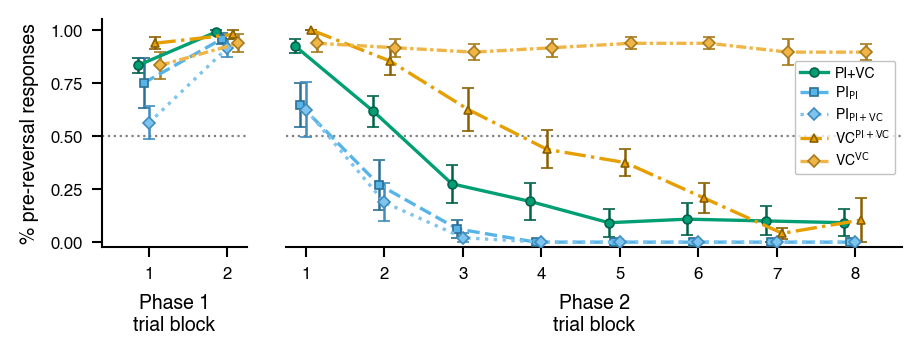

In [25]:
# ============================ knobs ==========================================
PERSEV_YLABEL = '% pre-reversal responses'
PERSEV_CHANCE = 0.5                       # dotted chance line (None = off)
ROW2_PANE_TITLES = None                   # e.g. ('Standard trials', 'Reversal trials') over E and F
# =============================================================================

def panel_c_perseveration(ax, **kw):
    opts = dict(group_acc=persev_mean, ylabel=PERSEV_YLABEL,
                show_criterion=PERSEV_CHANCE is not None, criterion_y=PERSEV_CHANCE or 0.5,
                ylim=(-0.025, 1.05), yticks=(0, 0.25, 0.5, 0.75, 1.0),
                split_phases=True, pane_titles=ROW2_PANE_TITLES, show_legend=False)
    opts.update(kw)
    return panel_b_accuracy(ax, **opts)

# Preview render: Panel 4E
fig = plt.figure(figsize=(4.6, 1.9))
ax = fig.add_axes([0.10, 0.29, 0.87, 0.60])
panel_c_perseveration(ax, show_legend=True, legend_loc='upper right', legend_bbox=(1.0, 0.85))
plt.show()

## Panel 4F — latency to first well: aggregation

Per-rat **mean** and per-rat **median** scores per block (`rat_lat_mean` / `rat_lat_med`); no
imputation — the panel hides group × block cells with fewer than `LAT_MIN_N` rats, and the
Phase-2 ANOVA uses the listwise blocks 1–`LAT_P2_BLOCKS` window.

In [26]:
# ============================ knob ===========================================
LAT_MIN_N     = 3      # Panel F: hide a group's block once fewer than this many rats still ran it
# =============================================================================

# --- Latency: per-rat MEAN and per-rat MEDIAN scores per block ----------------
rat_lat_mean = add_x_order(per_rat_block(probe, 'latency_s', 'mean'))
rat_lat_med  = add_x_order(per_rat_block(probe, 'latency_s', 'median'))
lat_mean      = mean_sem(rat_lat_mean, 'latency_s')          # group mean +- SEM of per-rat means
lat_mean_plot = lat_mean[lat_mean['n'] >= LAT_MIN_N].copy()  # plotted (Panel F)
lat_med       = median_iqr(rat_lat_mean, 'latency_s')        # group median +- IQR/2 of per-rat means
lat_medscore  = mean_sem(rat_lat_med, 'latency_s')           # group mean +- SEM of per-rat medians

_n = (rat_lat_mean.groupby(['group', 'phase', 'block'], observed=True)['subject_id']
      .nunique().unstack(['phase', 'block']).fillna(0).astype(int))
print('\nRats contributing per (group | phase.block) for latency (no imputation):')
print(_n.to_string())
print(f'Panel D hides cells with n < LAT_MIN_N = {LAT_MIN_N}: '
      f'{int((lat_mean["n"] < LAT_MIN_N).sum())} of {len(lat_mean)} group x block cells dropped.')

print('\nLatency (s), group MEAN of per-rat MEAN scores (plotted):')
print(_wide(lat_mean).round(2).to_string())
print('\nLatency (s), group MEAN of per-rat MEDIAN scores:')
print(_wide(lat_medscore).round(2).to_string())
print('\nLatency (s), group MEDIAN of per-rat MEAN scores:')
print(_wide(lat_med).round(2).to_string())


Rats contributing per (group | phase.block) for latency (no imputation):
phase     P1      P2                        
block      1   2   1   2   3   4  5  6  7  8
group                                       
PI+VC     15  15  15  15  15  11  6  4  3  3
PI_PI      6   6   6   6   6   2  2  2  1  1
PI_PI+VC   6   6   6   6   5   3  1  1  0  0
VC^PI+VC   6   6   6   6   6   6  6  6  6  6
VC^VC      6   6   6   6   6   6  6  6  6  6
Panel D hides cells with n < LAT_MIN_N = 3: 7 of 48 group x block cells dropped.

Latency (s), group MEAN of per-rat MEAN scores (plotted):
x_order      0     1     2     3     4     5     6     7     8     9
group                                                               
PI+VC     4.71  4.10  4.77  5.22  4.86  4.78  4.85  5.14  5.23  5.28
PI_PI     4.91  4.97  5.11  5.17  4.87  4.76  4.83  4.84  4.75  5.40
PI_PI+VC  5.65  5.07  5.85  5.09  4.92  5.06  4.59  4.66   NaN   NaN
VC^PI+VC  4.19  3.99  3.96  4.49  5.07  5.13  4.60  4.68  4.45  4.37
VC^VC     4.

### Assumption checks — Panel 4F

The same checks on the latency **mean**-score and **median**-score tables (Phase 1, and the
Phase-2 listwise window); note the right skew; log / rank robustness was checked in a retired development report.

In [27]:
mixed_assumptions(rat_lat_mean, 'latency_s',
                  f'LATENCY, per-rat MEAN scores (Panel F) -- P1 2x5 and P2 {LAT_P2_BLOCKS}x5 (listwise)',
                  k_blocks=LAT_P2_BLOCKS, skew_note=True)
mixed_assumptions(rat_lat_med, 'latency_s',
                  f'LATENCY, per-rat MEDIAN scores -- P1 2x5 and P2 {LAT_P2_BLOCKS}x5 (listwise)',
                  k_blocks=LAT_P2_BLOCKS, skew_note=True)

LATENCY, per-rat MEAN scores (Panel F) -- P1 2x5 and P2 3x5 (listwise)

[P1] group x block cells and the block2 - block1 change score (2 within levels -> the RM effect IS the change score; sphericity eps = 1):
   group  n                             b1                              b2                          change
   PI+VC 15 4.705 (0.650), Shapiro p=0.149 4.100 (0.592), Shapiro p=0.030* -0.605 (0.413), Shapiro p=0.847
   PI_PI  6 4.905 (0.938), Shapiro p=0.396  4.966 (0.812), Shapiro p=0.168  0.061 (0.447), Shapiro p=0.303
PI_PI+VC  6 5.650 (0.555), Shapiro p=0.058  5.075 (0.744), Shapiro p=0.283 -0.575 (0.429), Shapiro p=0.489
VC^PI+VC  6 4.190 (0.839), Shapiro p=0.563  3.991 (0.633), Shapiro p=0.518 -0.199 (0.312), Shapiro p=0.423
   VC^VC  6 4.715 (0.548), Shapiro p=0.672  4.337 (0.371), Shapiro p=0.392 -0.378 (0.616), Shapiro p=0.085
     Levene block 1 : W =  1.17, p = 0.3411  ok
     Levene block 2 : W =  0.78, p = 0.5430  ok
     Levene change  : W =  0.33, p = 0.8560  ok
    

     Normality per cell: 4/15 testable cells rejected (Shapiro p < .05); 0/15 cells constant.
     Levene block 1: W =  0.61, p = 0.6560  ok
     Levene block 2: W =  1.10, p = 0.3710  ok
     Levene block 3: W =  0.61, p = 0.6610  ok
     Mauchly: W = 0.8644, chi2(2) = 5.2, p = 0.0726 -> not rejected; eps_GG = 0.881
     Skew of window scores: +0.54 (right-skewed latency; log / rank / per-rat-median robustness were checked in a retired development report).


### Statistics — Panel 4F: the Panel-D tests on latency (mean and median scores)

In [28]:
SUMMARY.append(fig4b_stats(rat_lat_mean, 'latency_s',
                           'LATENCY -- per-rat MEAN scores (Panel F)', p2_blocks=LAT_P2_BLOCKS))
SUMMARY.append(fig4b_stats(rat_lat_med, 'latency_s',
                           'LATENCY -- per-rat MEDIAN scores', p2_blocks=LAT_P2_BLOCKS))


LATENCY -- per-rat MEAN scores (Panel F)



=== Phase 1: 2x5 mixed ANOVA (block within x group between) ===
     Source      SS  DF1  DF2     MS       F  p_unc    np2  eps
      group 12.6721    4   34 3.1680  3.9604 0.0096 0.3178  NaN
      block  3.1270    1   34 3.1270 31.8135 0.0000 0.4834  1.0
Interaction  1.1677    4   34 0.2919  2.9700 0.0331 0.2589  NaN

=== Phase 2: 3x5 mixed ANOVA (block within x group between) ===
Rats with all 3 Phase-2 blocks (listwise-complete): PI+VC 15, PI_PI 6, PI_PI+VC 5, VC^PI+VC 6, VC^VC 6  = 38 of 39
     Source     SS  DF1  DF2     MS      F  p_unc    np2    eps
      group 7.7939    4   33 1.9485 1.1305 0.3591 0.1205    NaN
      block 0.3865    2   66 0.1932 0.4031 0.6699 0.0121 0.9012
Interaction 7.0727    8   66 0.8841 1.8441 0.0843 0.1827    NaN

=== Bonferroni post-hocs: group main effect (block-averaged over blocks 1-3) ===
Block-averaged score by group:
          count   mean    sem
group                        
PI+VC        15  4.952  0.226
PI_PI         6  5.053  0.369
PI_PI+VC  


=== Phase 1: 2x5 mixed ANOVA (block within x group between) ===
     Source      SS  DF1  DF2     MS       F  p_unc    np2  eps
      group 10.2883    4   34 2.5721  3.9698 0.0095 0.3184  NaN
      block  0.5629    1   34 0.5629 24.2839 0.0000 0.4166  1.0
Interaction  0.2099    4   34 0.0525  2.2638 0.0826 0.2103  NaN

=== Phase 2: 3x5 mixed ANOVA (block within x group between) ===
Rats with all 3 Phase-2 blocks (listwise-complete): PI+VC 15, PI_PI 6, PI_PI+VC 5, VC^PI+VC 6, VC^VC 6  = 38 of 39
     Source     SS  DF1  DF2     MS      F  p_unc    np2    eps
      group 4.5516    4   33 1.1379 0.8896 0.4810 0.0973    NaN
      block 0.9414    2   66 0.4707 2.4810 0.0914 0.0699 0.8806
Interaction 3.4990    8   66 0.4374 2.3052 0.0303 0.2184    NaN

=== Bonferroni post-hocs: group main effect (block-averaged over blocks 1-3) ===
Block-averaged score by group:
          count   mean    sem
group                        
PI+VC        15  4.490  0.184
PI_PI         6  4.762  0.298
PI_PI+VC  

### Panel 4F — build

`panel_d_latency` wraps `panel_b_accuracy` with the latency aggregate and y-knobs; Panels E and F
share `ROW2_PANE_TITLES`.

Latency panel: ylim = (0, 7.36) s, ticks = [0.0, 2.0, 4.0, 6.0]


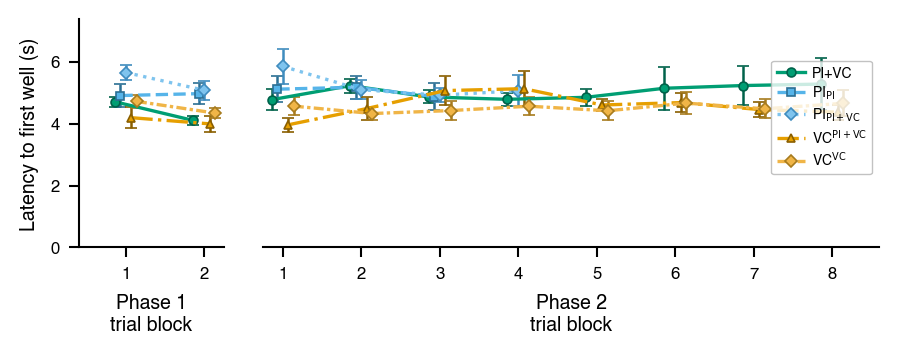

In [29]:
def _ylims(*accs, pad=1.15):
    """Latency y-range: 0 .. pad x max(mean + sem) over the given aggregates."""
    top = max(float((a['mean'] + a['sem'].fillna(0)).max()) for a in accs) * pad
    step = 1.0 if top <= 6 else 2.0 if top <= 14 else 5.0
    return (0, top), np.arange(0, top + 1e-9, step)

# ============================ knobs ==========================================
LAT_YLABEL    = 'Latency to first well (s)'
LAT_YLIM, LAT_YTICKS = _ylims(lat_mean_plot)   # or set by hand, e.g. (0, 8), (0, 2, 4, 6, 8)
# =============================================================================
print(f'Latency panel: ylim = (0, {LAT_YLIM[1]:.2f}) s, ticks = {[float(t) for t in LAT_YTICKS]}')

def panel_d_latency(ax, **kw):
    opts = dict(group_acc=lat_mean_plot, ylabel=LAT_YLABEL,
                show_criterion=False, ylim=LAT_YLIM, yticks=LAT_YTICKS,
                split_phases=True, pane_titles=ROW2_PANE_TITLES, show_legend=False)
    opts.update(kw)
    return panel_b_accuracy(ax, **opts)

# Preview render: Panel 4F
fig = plt.figure(figsize=(4.6, 1.9))
ax = fig.add_axes([0.10, 0.29, 0.87, 0.60])
panel_d_latency(ax, show_legend=True, legend_loc='upper right', legend_bbox=(1.0, 0.85))
plt.show()

### Panels E & F — headline p-value summary

In [30]:
# Headline p-values side by side (rows = test, columns = analysis). NaN = not applicable.
summary = pd.DataFrame(SUMMARY).set_index('analysis')
summary.index = [s.split(' -- ')[0] + ' | ' + s.split(' -- ')[1].split(' (')[0] for s in summary.index]
pd.set_option('display.float_format', lambda v: f'{v:.4f}' if v >= 1e-4 else f'{v:.1e}')
print(summary.T.to_string())
pd.reset_option('display.float_format')

                           PERSEVERATION | per-rat proportion, criterion-imputed  PERSEVERATION | rank-based  LATENCY | per-rat MEAN scores  LATENCY | per-rat MEDIAN scores
P1 group                                                                  0.0042                         NaN                         0.0096                           0.0095
P1 blk×grp                                                                0.0314                         NaN                         0.0331                           0.0826
P2 group                                                                 2.5e-10                     1.1e-05                         0.3591                           0.4810
P2 block                                                                 1.7e-66                         NaN                         0.6699                           0.0914
P2 blk×grp                                                               6.6e-18                         NaN                         0.

## Save standalone Panel 4B / 4E / 4F PDFs

## Compose Figure 4 — left column A | B | C, right column D | E | F

A 3 × 2 grid of 1.87 in rows. Left column: schematic (A, original size, centred), trials-to-
criterion box plots (B), Kaplan–Meier curves (C). Right column: accuracy (D), perseveration (E),
latency (F). Panel A is rasterized inline and replaced by the vector schematic in the exported SVG (next cell).

Panel B spine -> top of E's x-titles: y = 0.4266 -> 0.3860 (page fraction; axes height 0.2100 -> 0.2506); B's group labels reach down to y = 0.3521, row boundary at 0.3333


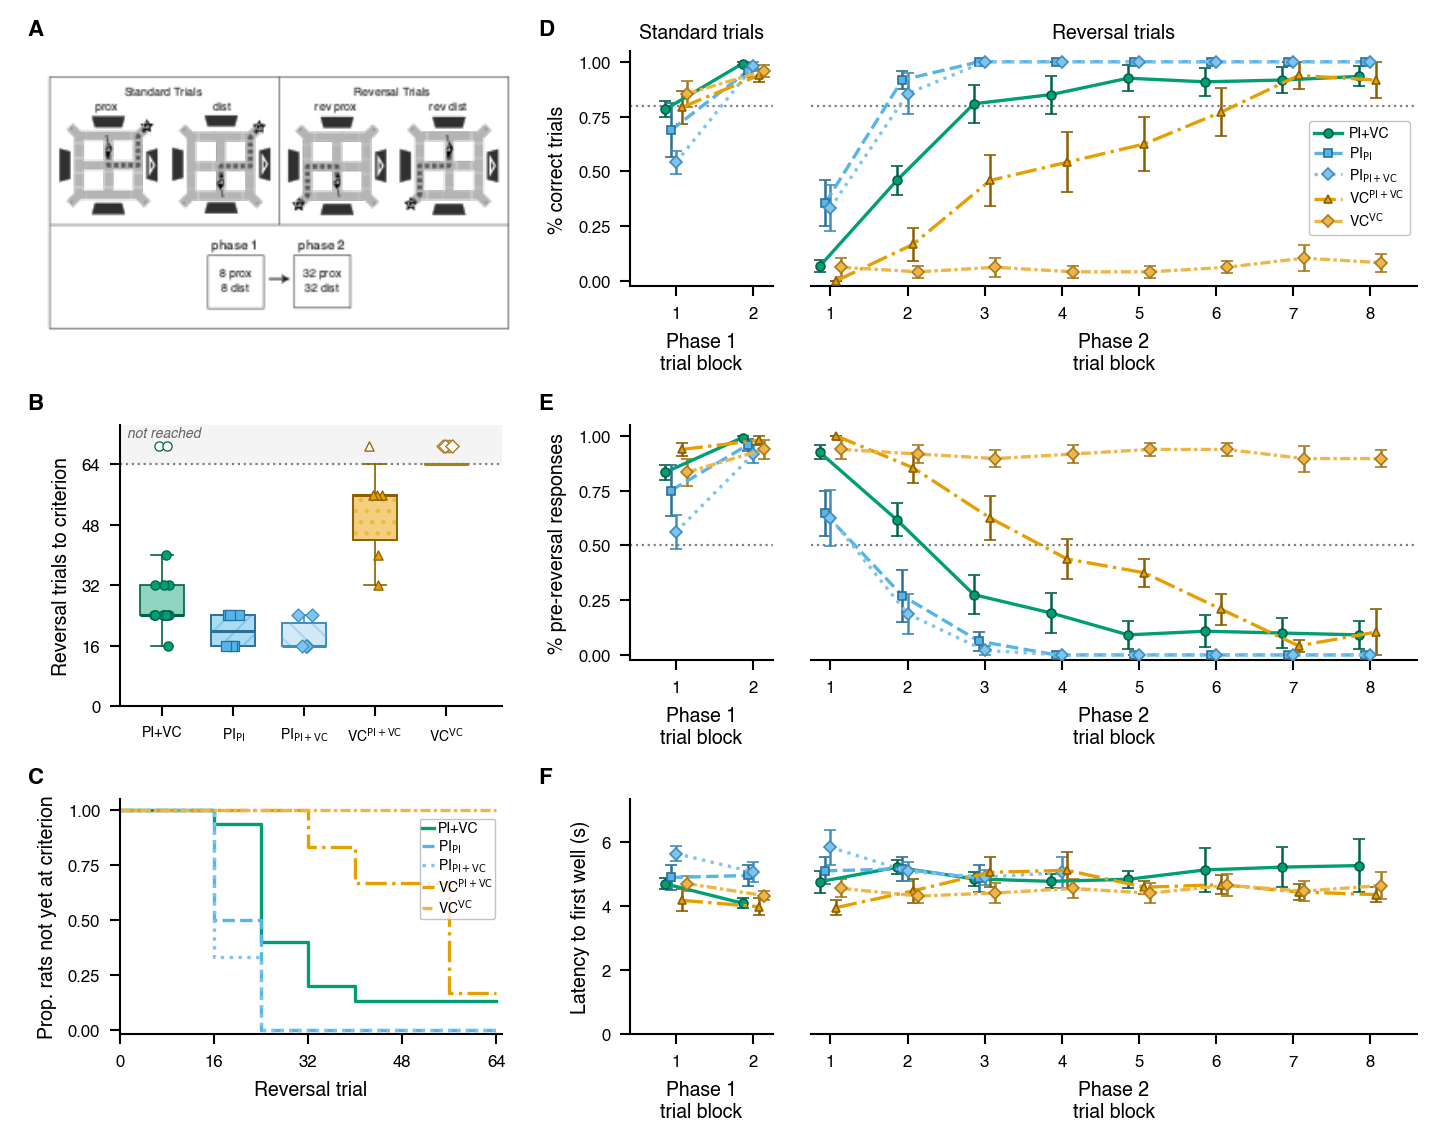

In [31]:
# Composed figure: raster Panel A inline, then replace with a vector overlay
# of fig_4a.svg in the exported SVG (next cell; same machinery as figure3).
page_w = 180 / 25.4   # Wiley full-page canvas: 180 mm = 7.087 in (was 7.5 in = 190.5 mm)
row_h  = 1.87            # one grid row = figure2 row height
page_h = row_h * 3

# Panel rectangles in figure fractions: [left, bottom, width, height]. 3 x 2 grid:
# LEFT column A | B | C (schematic, TTC box plots, Kaplan-Meier); RIGHT column D | E | F.
positions = {
    'A': [0.000, 2 / 3, 0.360, 1 / 3],
    'B': [0.000, 1 / 3, 0.360, 1 / 3],
    'C': [0.000, 0.0, 0.360, 1 / 3],
    'D': [0.360, 2 / 3, 0.640, 1 / 3],
    'E': [0.360, 1 / 3, 0.640, 1 / 3],
    'F': [0.360, 0.0, 0.640, 1 / 3],
}
# Pads in page fractions. D, E and F share one pad set -> identical axes widths and
# aligned y-axes; B and C share the left-column pad set.
ROW_PAD  = {'left': 0.070, 'right': 0.015, 'top': 0.030, 'bottom': 0.0933}   # right column
LEFT_PAD = {'left': 0.070, 'right': 0.020, 'top': 0.030, 'bottom': 0.0933}   # B and C
# --- Panel A sizing: keep the schematic at its original rendered size, centred ------
# The diagram fills the axes WIDTH (svg aspect 312.89/183.16 = 1.708), so A_WIDTH_IN
# sets its rendered width directly; equal left/right pads centre it in the column and
# equal top/bottom pads centre it in its row (0.030 leaves the axes 1.53 in tall, just
# above the 1.50 in diagram, and keeps the panel letter above the overlay's white cover).
A_WIDTH_IN = 2.556       # rendered schematic width in inches (the original 2x2-layout size)
_a_pad = (0.360 - A_WIDTH_IN / page_w) / 2
panel_pad = {
    'A': {'left': _a_pad, 'right': _a_pad, 'top': 0.030, 'bottom': 0.030},
    'B': dict(LEFT_PAD), 'C': dict(LEFT_PAD),
    'D': dict(ROW_PAD), 'E': dict(ROW_PAD), 'F': dict(ROW_PAD),
}

def axes_rect(name):
    pl, pb, pw, ph = positions[name]
    pad = panel_pad[name]
    return [pl + pad['left'], pb + pad['bottom'],
            pw - pad['left'] - pad['right'], ph - pad['top'] - pad['bottom']]

label_fontsize = 8
label_x_offset = 0.005
label_y_offset = 0.0017      # a third of the single-row value (page is three rows tall)

panel_a_path = PROJECT_ROOT / 'figures' / 'images' / 'fig_4a.svg'
panel_a_dpi = 600
panel_a_interpolation = 'bilinear'

show_a, show_b, show_c, show_d, show_e, show_f = True, True, True, True, True, True

fig = plt.figure(figsize=(page_w, page_h))

if show_a:
    ax_a = fig.add_axes(axes_rect('A'))
    if panel_a_path.exists():
        import cairosvg, io
        from PIL import Image
        png_data = cairosvg.svg2png(url=str(panel_a_path), dpi=panel_a_dpi)
        img = np.array(Image.open(io.BytesIO(png_data)))
        im_a = ax_a.imshow(img, aspect='equal', interpolation=panel_a_interpolation)
        im_a.set_clip_on(False)
    else:
        ax_a.text(0.5, 0.5, 'A\n(SVG missing — drop fig_4a.svg into figures/images/)',
                  ha='center', va='center', fontsize=8, color='gray',
                  transform=ax_a.transAxes)
    ax_a.set_axis_off()

if show_b:
    ax_b = fig.add_axes(axes_rect('B'))
    panel_b_ttc(ax_b)

if show_c:
    ax_c = fig.add_axes(axes_rect('C'))
    plot_ttc_km(ax_c, show_legend=True,                     # key in the empty upper-right pocket:
                legend_loc='upper right',                   # under the VC^VC line at 1.0, bottom above 0.5,
                legend_bbox=(1.0, 0.945),                   # left edge clear of the vertical at x = 48
                legend_fontsize=5, legend_handlelength=0.8,  # fontsize 5 = same as Panel D's legend
                legend_borderpad=0.2, legend_handletextpad=0.3,
                legend_labelspacing=0.15)

if show_d:
    ax_d = fig.add_axes(axes_rect('D'))
    panel_b_accuracy(ax_d, split_phases=True,               # Phase 1 | Phase 2 on two panes
                     pane_titles=('Standard trials', 'Reversal trials'),
                     show_legend=True, legend_loc='lower right',
                     legend_bbox=(1.0, 0.19),               # right-pane axes-frac; 0.19 clears the VC^VC block-7 error bar (was 0.15)
                     legend_fontsize=5, legend_frameon=True)

if show_e:
    ax_e = fig.add_axes(axes_rect('E'))
    panel_c_perseveration(ax_e, show_legend=False)          # key carried by Panel D

if show_f:
    ax_f = fig.add_axes(axes_rect('F'))
    panel_d_latency(ax_f, show_legend=False)

# --- Panel B: drop its x-axis spine to Panel E's x-axis titles --------------------------------
# Panel B has only tick labels under its spine, Panel E (same row) has tick labels plus the two-line
# 'Phase 1 / trial block' titles, so B's plot area stopped well above E's text. Extend B's axes down
# so its spine sits on the TOP (or bottom) edge of E's x-title text box, measured from the rendered
# figure; B's group labels then hang below that line, in the row's bottom pad.
B_SPINE_TO_E_XLABEL = True     # False = keep B's spine on the shared LEFT_PAD bottom (level with E's spine)
B_SPINE_TARGET = 'top'         # edge of E's 'Phase 1 / trial block' text box to sit on: 'top' | 'bottom'
B_SPINE_OFFSET_IN = 0.0        # extra vertical nudge of B's spine in inches (+ = up, e.g. 0.05 lifts B's group labels off the row boundary)
if show_b and show_e and B_SPINE_TO_E_XLABEL:
    fig.canvas.draw()
    _rend = fig.canvas.get_renderer()
    _panes = [ax_e] + ([ax_e.right_pane] if hasattr(ax_e, 'right_pane') else [])
    _to_fig = fig.transFigure.inverted()
    _edge = {'top': 'y1', 'bottom': 'y0'}[B_SPINE_TARGET]
    _e_xlab_y0 = min(_to_fig.transform((0, getattr(p.xaxis.label.get_window_extent(_rend), _edge)))[1]
                     for p in _panes)
    _bl, _bb, _bw, _bh = ax_b.get_position().bounds
    _e_xlab_y0 += B_SPINE_OFFSET_IN / page_h
    ax_b.set_position([_bl, _e_xlab_y0, _bw, _bb + _bh - _e_xlab_y0])
    fig.canvas.draw()
    _b_lab_y0 = min(_to_fig.transform((0, t.get_window_extent(_rend).y0))[1]
                    for t in ax_b.get_xticklabels())
    print(f"Panel B spine -> {B_SPINE_TARGET} of E's x-titles: y = {_bb:.4f} -> {_e_xlab_y0:.4f} (page fraction; axes height {_bh:.4f} -> "
          f"{_bb + _bh - _e_xlab_y0:.4f}); B's group labels reach down to y = {_b_lab_y0:.4f}, "
          f"row boundary at {positions['B'][1]:.4f}"
          + ('' if _b_lab_y0 >= positions['B'][1] else '  ** WARNING: labels cross into Panel C\'s row **'))

# Panel labels (top-left of each panel box)
show_panels = {'A': show_a, 'B': show_b, 'C': show_c, 'D': show_d, 'E': show_e, 'F': show_f}
panel_labels = {n: n for n in 'ABCDEF'}
for name, rect in positions.items():
    if not show_panels.get(name, False):
        continue
    text = panel_labels.get(name)
    if text is None:
        continue
    lx = rect[0] + label_x_offset
    ly = rect[1] + rect[3] - label_y_offset
    fig.text(lx, ly, text, fontsize=label_fontsize, fontweight='bold',
             va='top', ha='left')

plt.show()

In [32]:
# Export the composed figure as a fully-vector SVG.
#
# We build the SVG directly instead of converting the finished PDF with
# `pdftocairo -svg`: the PDF's schematic panels are pikepdf `add_overlay` Form
# XObjects (nested transform + BBox clip), and pdftocairo's SVG backend can
# mis-apply that nesting and scramble the clipped/dashed artwork (this broke
# figure3's Panel A). Instead we save matplotlib's own SVG (vector plot panels +
# labels; schematic panels rasterized) and splice each pristine source SVG in
# over its panel as a nested <svg>, so the schematics stay pixel-perfect vector.
#
# Each Illustrator export carries a global <style> (.st0..) and element ids
# (clippath..). SVG CSS/ids are document-global, so inlining more than one would
# collide (this scrambled figure2's two schematics). `_isolate` prefixes every
# class token and id (and their url(#..)/href references) per panel first.
#
# Hatching: matplotlib writes bar hatches as SVG <pattern> fills, and Adobe
# Illustrator (30.2, seen 2026-09-23) silently drops those on import - figure2's
# composed SVG lost every hatched bar the first time it was opened and re-saved
# in AI (the PDF's native pattern fills were fine). `_expand_hatches` therefore
# rewrites each `fill: url(#h..)` as the same drawing done explicitly - face
# fill, copies of the tile's hatch strokes (each clipped to its 72x72 tile, all
# clipped to the shape), then the shape's edge on top - i.e. what AI's own
# Object > Expand produces; plain paths + clipPaths survive every renderer.
# Same cell in figure2/3/4; figure5 reuses
# the helpers.
import math
import re
import xml.etree.ElementTree as ET

_NS = 'http://www.w3.org/2000/svg'
_IMG = f'{{{_NS}}}image'
ET.register_namespace('', _NS)
ET.register_namespace('xlink', 'http://www.w3.org/1999/xlink')

# (panel-rect key, source SVG) for every rasterized schematic panel.
_schematics = []
if show_a and panel_a_path.exists():
    _schematics.append(('A', panel_a_path))

def _isolate(root, prefix):
    """Prefix this SVG's class tokens and ids (+ their references) so its global
    styles/ids cannot collide with another inlined SVG's."""
    ids, classes = set(), set()
    for el in root.iter():
        if el.get('id'):
            ids.add(el.get('id'))
        if el.get('class'):
            classes.update(el.get('class').split())
    for st in root.iter(f'{{{_NS}}}style'):
        classes.update(re.findall(r'\.([A-Za-z_][\w-]*)', st.text or ''))

    def _fix(v):
        return re.sub(r'url\(#([^)]+)\)',
                      lambda m: f'url(#{prefix}{m.group(1)})' if m.group(1) in ids
                      else m.group(0), v)
    for el in root.iter():
        if el.get('id') in ids:
            el.set('id', prefix + el.get('id'))
        if el.get('class'):
            el.set('class', ' '.join(prefix + t for t in el.get('class').split()))
        for k, v in list(el.attrib.items()):
            if 'url(#' in v:
                el.set(k, _fix(v))
            if (k == 'href' or k.endswith('}href')) and v.startswith('#') and v[1:] in ids:
                el.set(k, '#' + prefix + v[1:])
    for st in root.iter(f'{{{_NS}}}style'):
        css = st.text or ''
        for t in sorted(classes, key=len, reverse=True):
            css = re.sub(r'\.' + re.escape(t) + r'\b', f'.{prefix}{t}', css)
        st.text = _fix(css)
    return root


def _translate_d(d, dx, dy):
    """Shift an absolute-command path (M/L/Q/C/Z, as matplotlib writes) by (dx, dy)."""
    out, i = [], 0
    for t in re.findall(r'[A-Za-z]|-?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?', d):
        if t.isalpha():
            if t not in 'MLQCZz':
                raise ValueError(f'unsupported path command {t!r}')
            out.append(t)
            i = 0
        else:
            out.append(f'{float(t) + (dx if i % 2 == 0 else dy):g}')
            i += 1
    return ' '.join(out)


def _expand_hatches(root):
    """Replace every `fill: url(#..)` that points at a matplotlib hatch <pattern>
    (a userSpaceOnUse tile in the document's own <defs>) with the same drawing done
    explicitly: the face fill (if the tile has one), then copies of the tile's
    hatch strokes - each clipped to its tile, all clipped to the shape - then the
    shape's own edge stroke on top. The now-unused <pattern> defs are removed.
    Returns the number of shapes expanded."""
    defs = root.findall(f'{{{_NS}}}defs')
    patterns = {p.get('id'): (d, p) for d in defs for p in d.findall(f'{{{_NS}}}pattern')
                if p.get('patternUnits') == 'userSpaceOnUse' and p.get('width') and p.get('height')}
    if not patterns:
        return 0
    parent = {c: p for p in root.iter() for c in p}
    num = r'-?(?:\d+\.?\d*|\.\d+)(?:[eE][-+]?\d+)?'
    n_shape = n_tile = 0
    for el in list(root.iter()):
        st = el.get('style') or ''
        m = re.search(r'fill:\s*url\(#([^)]+)\)', st)
        if not m or m.group(1) not in patterns or el.tag != f'{{{_NS}}}path' or not el.get('d'):
            continue
        pat = patterns[m.group(1)][1]
        tw, th = float(pat.get('width')), float(pat.get('height'))
        px, py = float(pat.get('x', 0)), float(pat.get('y', 0))
        shape_d = el.get('d')
        nums = [float(v) for v in re.findall(num, shape_d)]
        x0, x1, y0, y1 = min(nums[0::2]), max(nums[0::2]), min(nums[1::2]), max(nums[1::2])
        # matplotlib's tile = a background rect (the face colour; 'none' for a
        # hatch-only overlay) + the hatch strokes. A shape drawn with an edge keeps
        # its stroke-* properties next to the pattern fill in the same style string.
        rect = pat.find(f'{{{_NS}}}rect')
        face = rect.get('fill', 'none') if rect is not None else 'none'
        content = list(pat.iter(f'{{{_NS}}}path'))
        props = [p.strip() for p in st.split(';') if p.strip() and not p.strip().startswith('fill:')]
        stroke = [p for p in props if p.startswith('stroke')]
        other = [p for p in props if not p.startswith('stroke')]      # opacity, fill-opacity
        n_shape += 1
        cid = f'hatchshape{n_shape}'
        cp = ET.SubElement(defs[0], f'{{{_NS}}}clipPath', {'id': cid})
        ET.SubElement(cp, f'{{{_NS}}}path', {'d': shape_d})
        outer = ET.Element(f'{{{_NS}}}g')
        for k, v in el.attrib.items():          # keep the shape's clip-path / id / transform
            if k not in ('d', 'style'):
                outer.set(k, v)
        if other:
            outer.set('style', '; '.join(other))
        if face != 'none':                                             # 1) face fill
            ET.SubElement(outer, f'{{{_NS}}}path', {'d': shape_d, 'style': f'fill: {face}; stroke: none'})
        shape_g = ET.SubElement(outer, f'{{{_NS}}}g', {'clip-path': f'url(#{cid})'})   # 2) hatch
        for i in range(math.floor((x0 - px) / tw), math.ceil((x1 - px) / tw)):
            for j in range(math.floor((y0 - py) / th), math.ceil((y1 - py) / th)):
                dx, dy = px + i * tw, py + j * th
                n_tile += 1
                tid = f'hatchtile{n_tile}'
                tcp = ET.SubElement(defs[0], f'{{{_NS}}}clipPath', {'id': tid})
                ET.SubElement(tcp, f'{{{_NS}}}rect', {'x': f'{dx:g}', 'y': f'{dy:g}',
                                                      'width': f'{tw:g}', 'height': f'{th:g}'})
                tg = ET.SubElement(shape_g, f'{{{_NS}}}g', {'clip-path': f'url(#{tid})'})
                for c in content:
                    try:
                        ET.SubElement(tg, f'{{{_NS}}}path',
                                      {'d': _translate_d(c.get('d'), dx, dy), 'style': c.get('style', '')})
                    except ValueError:      # relative/arc commands: shift by transform instead
                        ET.SubElement(tg, f'{{{_NS}}}path',
                                      {'d': c.get('d'), 'style': c.get('style', ''),
                                       'transform': f'translate({dx:g} {dy:g})'})
        if any(re.match(r'stroke:\s*(?!none)', p) for p in stroke):       # 3) edge on top
            ET.SubElement(outer, f'{{{_NS}}}path', {'d': shape_d, 'style': 'fill: none; ' + '; '.join(stroke)})
        p = parent[el]
        p.insert(list(p).index(el), outer)
        p.remove(el)
    for d, pat in patterns.values():
        d.remove(pat)
    for d in defs:                              # matplotlib's trailing hatch-only <defs>
        if len(d) == 0 and d in parent:
            parent[d].remove(d)
    return n_shape


_svg = FIG_OUT / 'figure4.svg'
fig.savefig(_svg)  # vector plot panels + labels; schematic panels are raster <image>

_tree = ET.parse(_svg)
_root = _tree.getroot()
_n_hatch = _expand_hatches(_root)
_n_spliced = 0

if _schematics:
    _fig_g = _root.find(f'{{{_NS}}}g')  # matplotlib wraps everything in <g id="figure_1">

    # In these figures the only <image> elements are the schematic panels we are
    # about to replace; assert the count so an unexpected raster can't be
    # silently dropped (leave the schematics rasterized if it is off).
    _img_parents = [(p, ch) for p in _root.iter() for ch in list(p) if ch.tag == _IMG]
    if len(_img_parents) == len(_schematics):
        # Insert the vector schematics where the first raster panel sat, so the
        # bold panel labels (added last -> drawn on top) stay visible.
        _insert_at = min(i for i, ch in enumerate(list(_fig_g))
                         if any(e.tag == _IMG for e in ch.iter()))
        for _p, _img in _img_parents:
            _p.remove(_img)
        # SVG user units = inches*72 with y pointing down, so flip the
        # bottom-origin fraction to a top y. 'meet' == imshow aspect='equal'.
        _doc_w, _doc_h = page_w * 72.0, page_h * 72.0
        for _k, (_name, _path) in enumerate(_schematics):
            _ax_l, _ax_b, _ax_w, _ax_h = axes_rect(_name)
            _a_root = _isolate(ET.parse(_path).getroot(), f'p{_k}_')
            # Strip the schematic's <metadata> and any Adobe-namespace elements
            # (Illustrator's private <aipgf> editing payload). Nested inside a
            # foreign document that blob makes Illustrator try - and fail - to
            # restore the original file instead of reading the SVG, so the
            # composed export would not open in AI. Metadata only; rendering
            # is unaffected (the pristine source SVG keeps its payload).
            _AI = '{http://ns.adobe.com/AdobeIllustrator/10.0/}'
            for _parent in list(_a_root.iter()):
                for _ch in [c for c in list(_parent)
                            if c.tag == f'{{{_NS}}}metadata' or str(c.tag).startswith(_AI)]:
                    _parent.remove(_ch)
            _nested = ET.Element(f'{{{_NS}}}svg')
            _nested.set('x', f'{_ax_l * _doc_w:.4f}')
            _nested.set('y', f'{(1.0 - _ax_b - _ax_h) * _doc_h:.4f}')
            _nested.set('width', f'{_ax_w * _doc_w:.4f}')
            _nested.set('height', f'{_ax_h * _doc_h:.4f}')
            _nested.set('viewBox', _a_root.get('viewBox'))
            _nested.set('preserveAspectRatio', 'xMidYMid meet')
            for _child in list(_a_root):
                _nested.append(_child)
            _fig_g.insert(_insert_at, _nested)
        _n_spliced = len(_schematics)
    else:
        print(f'WARNING: found {len(_img_parents)} <image> element(s), expected '
              f'{len(_schematics)}; schematics left rasterized: {_svg}')

_tree.write(_svg, xml_declaration=True, encoding='utf-8')
print(f'Saved SVG: {_svg} ({_n_spliced} schematic panel(s) spliced in as vector; '
      f'{_n_hatch} hatched shape(s) expanded to plain strokes)')

Saved SVG: figures/images/figure4.svg (1 schematic panel(s) spliced in as vector; 4 hatched shape(s) expanded to plain strokes)
